# Medical Language Model from Scratch

In this notebook we build a **tiny clinical GPT** from scratch on one dataset, then post-train it twice (SFT, GRPO). Every stage — tokenization, embeddings, attention, pretraining, supervised fine-tuning, and reinforcement learning — uses the same model and the same clinical-note-to-JSON task.

**Dataset:** [`AGBonnet/augmented-clinical-notes`](https://huggingface.co/datasets/AGBonnet/augmented-clinical-notes) (MIT license, synthetic/PMC-Patients)

### Contents

| Section | Topic |
|---------|-------|
| [1](#data) | Data Tour and Framing |
| [2](#tokenization) | Tokenization, Token IDs, Embeddings |
| [3](#attention) | Attention and the Tiny Transformer |
| [4](#pretraining) | Pretraining by Next-Token Prediction |
| [5](#sft) | SFT on Structured Extraction |
| [6](#dpo) | Direct Preference Optimization (DPO) |
| [7](#grpo) | GRPO with Rule-Based Rewards |
| [8](#compare) | Compare the Models |
| [9](#peft) | Parameter-Efficient Fine-Tuning (PEFT) |

In [1]:
# ── Section 0: Setup and Environment ──────────────────────────────────────────
import sys, subprocess

def pip_install(packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

# Upgrade HF ecosystem packages (Colab's pre-installed versions are too old).
# Do NOT upgrade numpy/scipy/matplotlib/seaborn/pandas — Colab's pre-installed
# versions are mutually compatible; upgrading any of them breaks C-extension linkage.
pip_install([
    "-U", "transformers", "datasets", "tokenizers", "trl", "peft",
    "accelerate", "huggingface_hub", "wordcloud",
])

import torch, transformers, datasets, trl, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display, HTML

print(f"torch: {torch.__version__}")
print(f"transformers: {transformers.__version__}")
print(f"trl: {trl.__version__}")
print(f"numpy: {np.__version__}")

# GPU detection
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("No GPU — running on CPU (training will be slow)")

# Toggle: set True to skip training and load precomputed checkpoints
USE_PRECOMPUTED = False
CHECKPOINT_DIR = "clinical_gpt_checkpoints"  # local directory or HF Hub path

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Matplotlib defaults for lecture readability — all text black
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
})
sns.set_style("whitegrid")

torch: 2.10.0+cu128
transformers: 5.3.0
trl: 0.29.0
numpy: 2.0.2
GPU: Tesla T4


In [2]:
# Helper functions used throughout the notebook
import json, textwrap

def generate_text(model, tokenizer, prompt, max_new_tokens=128, temperature=0.7):
    """Generate text from a prompt."""
    model.eval()
    max_prompt_len = model.config.n_positions - max_new_tokens
    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=max_prompt_len,
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            temperature=temperature, do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)


def plot_training_curve(log_history, metric="loss", title="Training Loss"):
    """Plot a metric from Trainer log_history."""
    steps = [e["step"] for e in log_history if metric in e]
    values = [e[metric] for e in log_history if metric in e]
    plt.figure(figsize=(8, 4))
    plt.plot(steps, values, linewidth=2)
    plt.xlabel("Step")
    plt.ylabel(metric.replace("_", " ").title())
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_train_eval_curves(log_history, train_metric="loss", eval_metric="eval_loss", title="Training vs Test Loss", eval_label="Test loss"):
    """Plot train and eval metrics from Trainer log_history on the same axes."""
    train_steps = [e["step"] for e in log_history if train_metric in e]
    train_values = [e[train_metric] for e in log_history if train_metric in e]
    eval_steps = [e["step"] for e in log_history if eval_metric in e]
    eval_values = [e[eval_metric] for e in log_history if eval_metric in e]

    plt.figure(figsize=(8, 4))
    if train_steps:
        plt.plot(train_steps, train_values, linewidth=2, label="Train loss", color="steelblue")
    if eval_steps:
        plt.plot(eval_steps, eval_values, linewidth=2, label=eval_label, color="coral")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.title(title)
    if train_steps or eval_steps:
        plt.legend()
    plt.tight_layout()
    plt.show()


def display_comparison_table(rows, columns, title=""):
    """Render an HTML table for side-by-side comparison."""
    html = f'<h3 style="color:black;">{title}</h3>' if title else ""
    html += '<table style="width:100%; border-collapse:collapse; font-size:13px; color:black;">'
    html += "<tr>" + "".join(f'<th style="border:1px solid #ccc; padding:8px; background:#f0f0f0; color:black;">{c}</th>' for c in columns) + "</tr>"
    for row in rows:
        html += "<tr>" + "".join(
            f'<td style="border:1px solid #ccc; padding:8px; vertical-align:top; white-space:pre-wrap; color:black;">{cell}</td>'
            for cell in row
        ) + "</tr>"
    html += "</table>"
    display(HTML(html))

<a id="data"></a>

---
## Section 1: Data Tour and Framing

Electronic health records (EHRs) are overwhelmingly **unstructured text** — discharge summaries, progress notes, radiology reports. Extracting structured information from these notes is a core challenge in clinical NLP.

We use the [`AGBonnet/augmented-clinical-notes`](https://huggingface.co/datasets/AGBonnet/augmented-clinical-notes) dataset (MIT license). Each row contains four aligned views of the same clinical case:

| Column | Description |
|--------|-------------|
| `note` | A short clinical note (~1–2 paragraphs) |
| `full_note` | A longer version of the same note |
| `summary` | A structured JSON object with patient demographics, diagnoses, medications |
| `conversation` | A doctor–patient dialog version |

**Our task:** extract the `summary` JSON from the `note`. This is a realistic clinical NLP task — turning free-text notes into structured data.

In [3]:
# Load dataset
from datasets import load_dataset

full_ds = load_dataset("AGBonnet/augmented-clinical-notes", split="train[:3000]")
print(f"Loaded {len(full_ds)} examples")
print(f"Columns: {full_ds.column_names}")
print(f"First example keys: {list(full_ds[0].keys())}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loaded 3000 examples
Columns: ['idx', 'note', 'full_note', 'conversation', 'summary']
First example keys: ['idx', 'note', 'full_note', 'conversation', 'summary']


In [4]:
# Create train / val / test splits using datasets library
split1 = full_ds.train_test_split(test_size=0.2, seed=SEED)
train_ds = split1["train"]
split2 = split1["test"].train_test_split(test_size=0.5, seed=SEED)
val_ds = split2["train"]
test_ds = split2["test"]

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 2400, Val: 300, Test: 300


In [5]:
# Display one example record
ex = train_ds[0]
html = '<div style="font-family: monospace; font-size: 12px; color: black;">'
for field in ["note", "full_note", "summary", "conversation"]:
    val = ex.get(field, "N/A")
    preview = val[:500] + "..." if len(val) > 500 else val
    color = {"note": "#e3f2fd", "full_note": "#e8f5e9", "summary": "#fff3e0", "conversation": "#fce4ec"}[field]
    html += f'<div style="background:{color}; padding:10px; margin:5px 0; border-radius:5px; color:black;">'
    html += f'<b>{field}</b> ({len(val)} chars)<br><pre style="white-space:pre-wrap; color:black;">{preview}</pre></div>'
html += '</div>'
display(HTML(html))

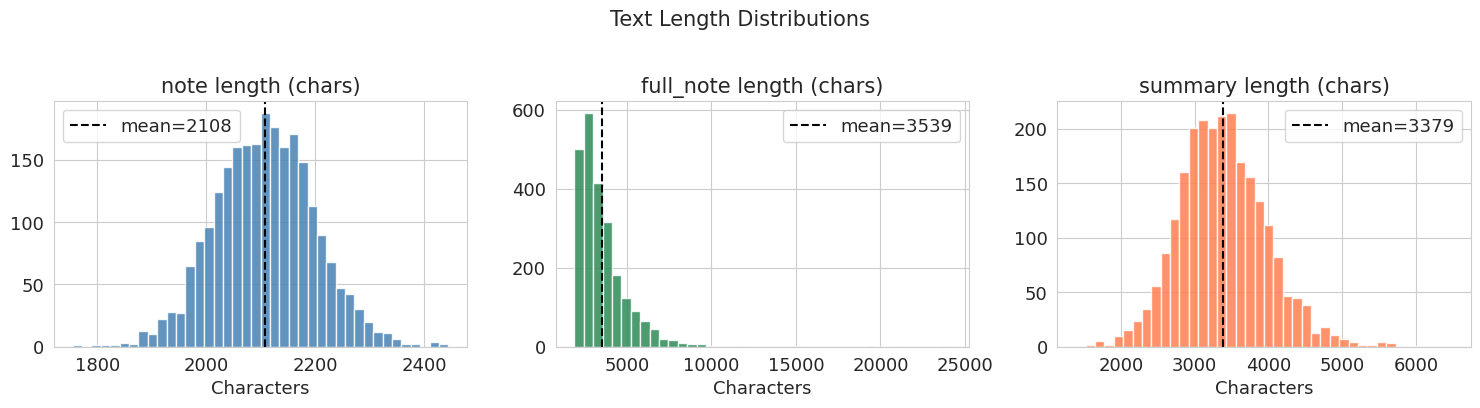

Teaching point: 'note' fits comfortably in a 256-token context; 'full_note' often does not.


In [6]:
# ── Visualization 1: Text length distributions ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, field, color in zip(axes, ["note", "full_note", "summary"],
                             ["steelblue", "seagreen", "coral"]):
    lengths = [len(ex[field]) for ex in train_ds]
    ax.hist(lengths, bins=40, color=color, edgecolor="white", alpha=0.85)
    mean_len = np.mean(lengths)
    ax.axvline(mean_len, color="black", linestyle="--", linewidth=1.5,
               label=f"mean={mean_len:.0f}")
    ax.set_title(f"{field} length (chars)")
    ax.set_xlabel("Characters")
    ax.legend()

fig.suptitle("Text Length Distributions", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("Teaching point: 'note' fits comfortably in a 256-token context; 'full_note' often does not.")

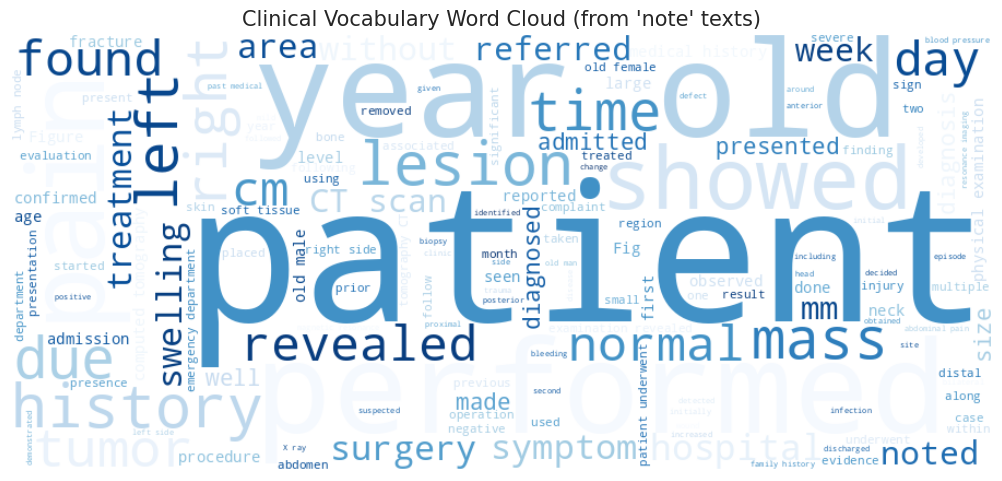

Teaching point: clinical text has a distinctive vocabulary — diagnoses, medications, body systems.


In [7]:
# ── Visualization 2: Word cloud of clinical vocabulary ──
from wordcloud import WordCloud

all_notes = " ".join(ex["note"] for ex in train_ds)
wc = WordCloud(width=900, height=400, background_color="white",
               colormap="Blues", max_words=150).generate(all_notes)

plt.figure(figsize=(12, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Clinical Vocabulary Word Cloud (from 'note' texts)")
plt.tight_layout()
plt.show()
print("Teaching point: clinical text has a distinctive vocabulary — diagnoses, medications, body systems.")

Successfully parsed 1828/2400 summaries as JSON


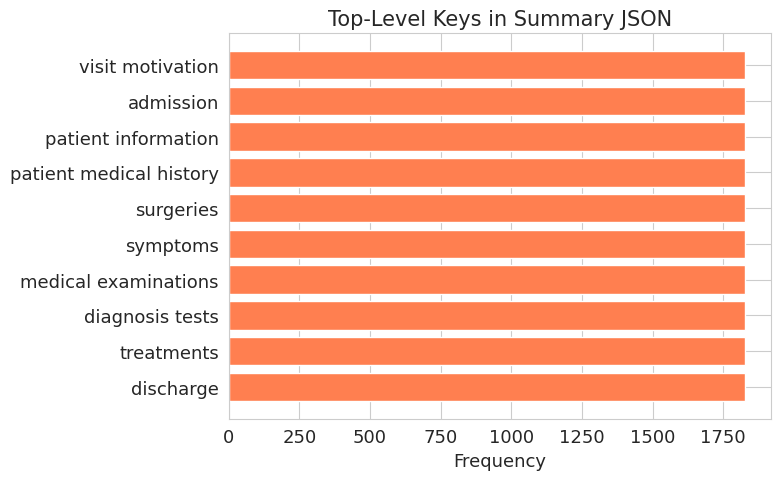

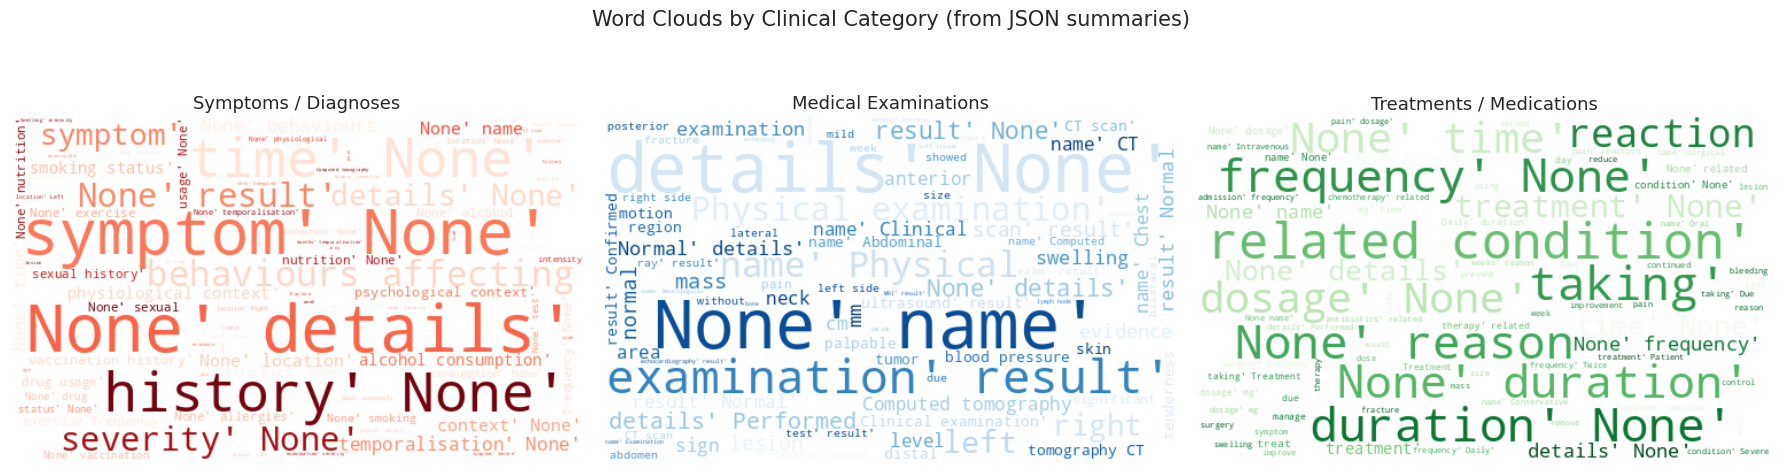

Teaching point: the JSON summaries capture distinct clinical domains — symptoms, exams, treatments.


In [8]:
# ── Visualization 3: Summary JSON structure & category word clouds ──
from collections import Counter
from wordcloud import WordCloud

key_counts = Counter()
symptoms_text, exams_text, treatments_text = [], [], []
parse_success = 0

for ex in train_ds:
    try:
        parsed = json.loads(ex["summary"])
        key_counts.update(parsed.keys())
        parse_success += 1
        # Collect text for category word clouds
        for key in parsed:
            val = str(parsed[key])
            kl = key.lower()
            if any(k in kl for k in ["symptom", "complaint", "present", "history", "diagnosis"]):
                symptoms_text.append(val)
            elif any(k in kl for k in ["exam", "test", "lab", "finding", "vital", "investigation"]):
                exams_text.append(val)
            elif any(k in kl for k in ["treatment", "medication", "drug", "prescription", "plan", "therapy"]):
                treatments_text.append(val)
    except (json.JSONDecodeError, TypeError):
        pass

print(f"Successfully parsed {parse_success}/{len(train_ds)} summaries as JSON")

# Top-level key bar chart
top_keys = key_counts.most_common(15)
keys, counts = zip(*top_keys) if top_keys else ([], [])

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(list(reversed(keys)), list(reversed(counts)), color="coral", edgecolor="white")
ax.set_xlabel("Frequency")
ax.set_title("Top-Level Keys in Summary JSON")
plt.tight_layout()
plt.show()

# Category word clouds: symptoms, examinations, treatments
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
categories = [
    ("Symptoms / Diagnoses", " ".join(symptoms_text), "Reds"),
    ("Medical Examinations", " ".join(exams_text), "Blues"),
    ("Treatments / Medications", " ".join(treatments_text), "Greens"),
]
for ax, (title, text, cmap) in zip(axes, categories):
    if text.strip():
        wc = WordCloud(width=500, height=300, background_color="white",
                       colormap=cmap, max_words=80).generate(text)
        ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=13)
    ax.axis("off")

fig.suptitle("Word Clouds by Clinical Category (from JSON summaries)", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("Teaching point: the JSON summaries capture distinct clinical domains — symptoms, exams, treatments.")

### Framing Recap

- **Input:** `note` — a short clinical note (fits in ~256 tokens)
- **Target:** `summary` — structured JSON with patient information
- **Important:** This data is synthetic (PMC-Patients + NoteChat). We are teaching the *pipeline*, not building a clinical deployment system.

Next: how do we turn text into numbers the model can process?

<a id="tokenization"></a>

---
## Section 2: Tokenization, Token IDs, Embeddings

Before a language model can process text, we must convert it to **tokens** — the atomic units the model works with.

| Approach | Example | Pros | Cons |
|----------|---------|------|------|
| Word-level | `["myocardial", "infarction"]` | Intuitive | Huge vocab, can't handle rare words |
| Character-level | `["m","y","o","c",...]` | Tiny vocab | Very long sequences, loses word meaning |
| **Subword (BPE)** | `["my", "ocard", "ial"]` | Balanced vocab, handles rare words | Needs training |

Modern LLMs use **Byte-Pair Encoding (BPE)**: start with characters, iteratively merge the most frequent adjacent pair. This produces a vocabulary that covers common medical terms as single tokens while handling rare variants gracefully.

In [9]:
# Load GPT-2's general-purpose tokenizer
from transformers import AutoTokenizer

gpt2_tokenizer = AutoTokenizer.from_pretrained("gpt2")

clinical_sentence = (
    "The patient presented with acute myocardial infarction "
    "and was prescribed metoprolol 50mg twice daily."
)

gpt2_tokens = gpt2_tokenizer.tokenize(clinical_sentence)
gpt2_ids = gpt2_tokenizer.encode(clinical_sentence)

print(f"GPT-2 tokens ({len(gpt2_tokens)}): {gpt2_tokens}")
print(f"GPT-2 IDs: {gpt2_ids}")

GPT-2 tokens (23): ['The', 'Ġpatient', 'Ġpresented', 'Ġwith', 'Ġacute', 'Ġmy', 'ocard', 'ial', 'Ġinf', 'ar', 'ction', 'Ġand', 'Ġwas', 'Ġprescribed', 'Ġmet', 'op', 'rol', 'ol', 'Ġ50', 'mg', 'Ġtwice', 'Ġdaily', '.']
GPT-2 IDs: [464, 5827, 5545, 351, 14352, 616, 44412, 498, 1167, 283, 596, 290, 373, 14798, 1138, 404, 3225, 349, 2026, 11296, 5403, 4445, 13]


### Tokenization step by step

Once you have a tokenizer, the workflow is: **raw text → tokens → token IDs → tensors**.

Models don't directly understand text — they use numerical representations called **token IDs**. Each token in the vocabulary has a unique integer ID. The tokenizer handles the conversion in both directions.

In [10]:
# Step-by-step tokenization with the GPT-2 tokenizer
text = "The patient presented with acute myocardial infarction."

# Step 1: Text → Tokens (subword strings)
tokens = gpt2_tokenizer.tokenize(text)
print("Step 1 — Tokens:", tokens)

# Step 2: Tokens → Token IDs (integers)
token_ids = gpt2_tokenizer.encode(text)
print("Step 2 — Token IDs:", token_ids)

# Step 3: Token IDs → back to tokens (round-trip verification)
tokens_back = gpt2_tokenizer.convert_ids_to_tokens(token_ids)
print("Step 3 — IDs back to tokens:", tokens_back)

# Step 4: Full pipeline — text → PyTorch tensors (what the model actually receives)
inputs = gpt2_tokenizer(text, return_tensors="pt")
print("\nStep 4 — Model input tensors:")
print(f"  input_ids shape: {inputs['input_ids'].shape}  (batch_size, seq_length)")
print(f"  input_ids: {inputs['input_ids']}")
print(f"  attention_mask: {inputs['attention_mask']}")

Step 1 — Tokens: ['The', 'Ġpatient', 'Ġpresented', 'Ġwith', 'Ġacute', 'Ġmy', 'ocard', 'ial', 'Ġinf', 'ar', 'ction', '.']
Step 2 — Token IDs: [464, 5827, 5545, 351, 14352, 616, 44412, 498, 1167, 283, 596, 13]
Step 3 — IDs back to tokens: ['The', 'Ġpatient', 'Ġpresented', 'Ġwith', 'Ġacute', 'Ġmy', 'ocard', 'ial', 'Ġinf', 'ar', 'ction', '.']

Step 4 — Model input tensors:
  input_ids shape: torch.Size([1, 12])  (batch_size, seq_length)
  input_ids: tensor([[  464,  5827,  5545,   351, 14352,   616, 44412,   498,  1167,   283,
           596,    13]])
  attention_mask: tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])


The `inputs` dictionary contains:

- **`input_ids`**: Token IDs with shape `(batch_size, sequence_length)` — these are the integers the model processes.
- **`attention_mask`**: A binary mask where `1` = real token and `0` = padding. This tells the model which positions to attend to.

You pass `inputs` to the model as `model(**inputs)` or equivalently `model(inputs['input_ids'], attention_mask=inputs['attention_mask'])`.

**Batching multiple sentences** requires **padding** so all sequences have the same length:

In [11]:
# Batching multiple sentences — padding makes them the same length
# GPT-2 has no pad token by default; set it to eos_token for this demo
if gpt2_tokenizer.pad_token is None:
    gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

texts = [
    "The patient presented with chest pain.",
    "Blood pressure was elevated at 160/95 mmHg on admission.",
    "Prescribed aspirin daily.",
]

batch_inputs = gpt2_tokenizer(texts, padding=True, return_tensors="pt")

print(f"Pad token: '{gpt2_tokenizer.pad_token}' | Pad token ID: {gpt2_tokenizer.pad_token_id}")
print(f"\ninput_ids shape: {batch_inputs['input_ids'].shape}  (batch=3, padded_length)")
print(f"\ninput_ids:\n{batch_inputs['input_ids']}")
print(f"\nattention_mask (1=real, 0=padding):\n{batch_inputs['attention_mask']}")

Pad token: '<|endoftext|>' | Pad token ID: 50256

input_ids shape: torch.Size([3, 14])  (batch=3, padded_length)

input_ids:
tensor([[  464,  5827,  5545,   351,  7721,  2356,    13, 50256, 50256, 50256,
         50256, 50256, 50256, 50256],
        [21659,  3833,   373, 15321,   379, 13454,    14,  3865,  8085,    39,
            70,   319, 13938,    13],
        [25460, 32968, 49550,  4445,    13, 50256, 50256, 50256, 50256, 50256,
         50256, 50256, 50256, 50256]])

attention_mask (1=real, 0=padding):
tensor([[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


In [12]:
# Train a domain BPE tokenizer on our clinical notes
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from transformers import PreTrainedTokenizerFast

def corpus():
    for ex in full_ds:
        yield ex["note"]
        yield ex["summary"]

tok = Tokenizer(BPE(unk_token="[UNK]"))
tok.pre_tokenizer = Whitespace()
trainer = BpeTrainer(vocab_size=8000, special_tokens=["[UNK]", "[PAD]", "[BOS]", "[EOS]"])
tok.train_from_iterator(corpus(), trainer=trainer, length=2 * len(full_ds))

# Wrap as a HuggingFace tokenizer
tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tok,
    unk_token="[UNK]",
    pad_token="[PAD]",
    bos_token="[BOS]",
    eos_token="[EOS]",
)

print(f"Domain tokenizer vocab size: {tokenizer.vocab_size}")

domain_tokens = tokenizer.tokenize(clinical_sentence)
domain_ids = tokenizer.encode(clinical_sentence)
print(f"Domain tokens ({len(domain_tokens)}): {domain_tokens}")

Domain tokenizer vocab size: 8000
Domain tokens (19): ['The', 'patient', 'presented', 'with', 'acute', 'myocardial', 'infarction', 'and', 'was', 'prescribed', 'me', 'to', 'pro', 'lol', '50', 'mg', 'twice', 'daily', '.']


### Special Tokens

When we built our domain tokenizer, we defined four **special tokens**:

| Token | Purpose |
|-------|---------|
| `[UNK]` | **Unknown** — placeholder for characters not in the vocabulary |
| `[PAD]` | **Padding** — fills shorter sequences to match the longest in a batch |
| `[BOS]` | **Beginning of Sequence** — marks the start of a text |
| `[EOS]` | **End of Sequence** — marks the end of a text (tells the model to stop generating) |

These tokens are assigned the first IDs in the vocabulary (0–3) and are essential for the model to understand sequence boundaries and handle variable-length inputs.

### How `PreTrainedTokenizerFast` organizes the tokenizer

The `PreTrainedTokenizerFast` wrapper from Hugging Face provides a unified interface on top of the raw `tokenizers` library:

1. **Vocabulary mapping** — maintains the token ↔ ID bijection from the trained BPE model
2. **Special token registration** — stores `bos_token`, `eos_token`, `pad_token`, `unk_token` and their IDs as named attributes
3. **Encoding pipeline** — `tokenizer(text)` runs: normalization → pre-tokenization → BPE merges → special token insertion → conversion to IDs
4. **Decoding pipeline** — `tokenizer.decode(ids)` reverses the process, stripping special tokens by default
5. **Batch handling** — supports padding, truncation, and `return_tensors` for direct model input

In [13]:
# Visualize special tokens in our domain tokenizer
print("Special tokens and their IDs:")
print(f"  [UNK] = {tokenizer.unk_token_id}")
print(f"  [PAD] = {tokenizer.pad_token_id}")
print(f"  [BOS] = {tokenizer.bos_token_id}")
print(f"  [EOS] = {tokenizer.eos_token_id}")

# Show how special tokens appear in an encoded sentence
example = "Patient has fever"
ids_no_special = tokenizer.encode(example, add_special_tokens=False)
ids_with_special = [tokenizer.bos_token_id] + ids_no_special + [tokenizer.eos_token_id]

tokens_display = tokenizer.convert_ids_to_tokens(ids_with_special)

# Color-coded HTML: special tokens highlighted
html = '<div style="font-family:monospace; color:black; font-size:13px;">'
html += '<b>Encoded with special tokens:</b><br><br>'
for tok_str, tok_id in zip(tokens_display, ids_with_special):
    is_special = tok_str in ["[BOS]", "[EOS]", "[PAD]", "[UNK]"]
    bg = "#ffcdd2" if is_special else "#e3f2fd"
    label = " (special)" if is_special else ""
    html += (f'<span style="background:{bg}; color:black; padding:3px 6px; margin:2px; '
             f'border-radius:4px; display:inline-block;">'
             f'{tok_str}<sub style="color:#666;">ID={tok_id}{label}</sub></span>')
html += '</div>'
display(HTML(html))

Special tokens and their IDs:
  [UNK] = 0
  [PAD] = 1
  [BOS] = 2
  [EOS] = 3


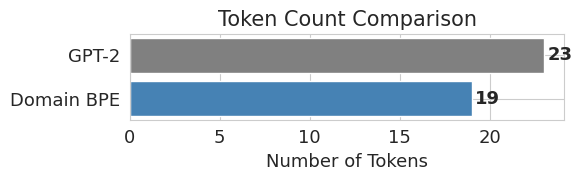

Teaching point: a domain tokenizer produces fewer tokens for clinical terms → more efficient.


In [14]:
# ── Visualization 4: Side-by-side tokenization comparison ──
import hashlib

def token_color(token, seed=0):
    h = int(hashlib.md5((token + str(seed)).encode()).hexdigest()[:6], 16)
    r, g, b = (h >> 16) & 0xFF, (h >> 8) & 0xFF, h & 0xFF
    # Lighten for readability
    r, g, b = 200 + r % 55, 200 + g % 55, 200 + b % 55
    return f"rgb({r},{g},{b})"

def render_tokens(tokens, label):
    spans = "".join(
        f'<span style="background:{token_color(t)}; color:black; padding:2px 4px; margin:1px; '
        f'border-radius:3px; display:inline-block; font-size:12px;">{t}</span>'
        for t in tokens
    )
    return f'<div style="margin:8px 0; color:black;"><b>{label} ({len(tokens)} tokens):</b><br>{spans}</div>'

html = '<div style="font-family:monospace; color:black;">'
html += f'<p style="color:black;"><i>"{clinical_sentence}"</i></p>'
html += render_tokens(gpt2_tokens, "GPT-2 (general)")
html += render_tokens(domain_tokens, "Domain (clinical BPE)")
html += '</div>'
display(HTML(html))

# Token count bar
fig, ax = plt.subplots(figsize=(6, 2))
ax.barh(["Domain BPE", "GPT-2"], [len(domain_tokens), len(gpt2_tokens)],
        color=["steelblue", "gray"])
ax.set_xlabel("Number of Tokens")
ax.set_title("Token Count Comparison")
for i, v in enumerate([len(domain_tokens), len(gpt2_tokens)]):
    ax.text(v + 0.2, i, str(v), va="center", fontweight="bold")
plt.tight_layout()
plt.show()
print("Teaching point: a domain tokenizer produces fewer tokens for clinical terms → more efficient.")

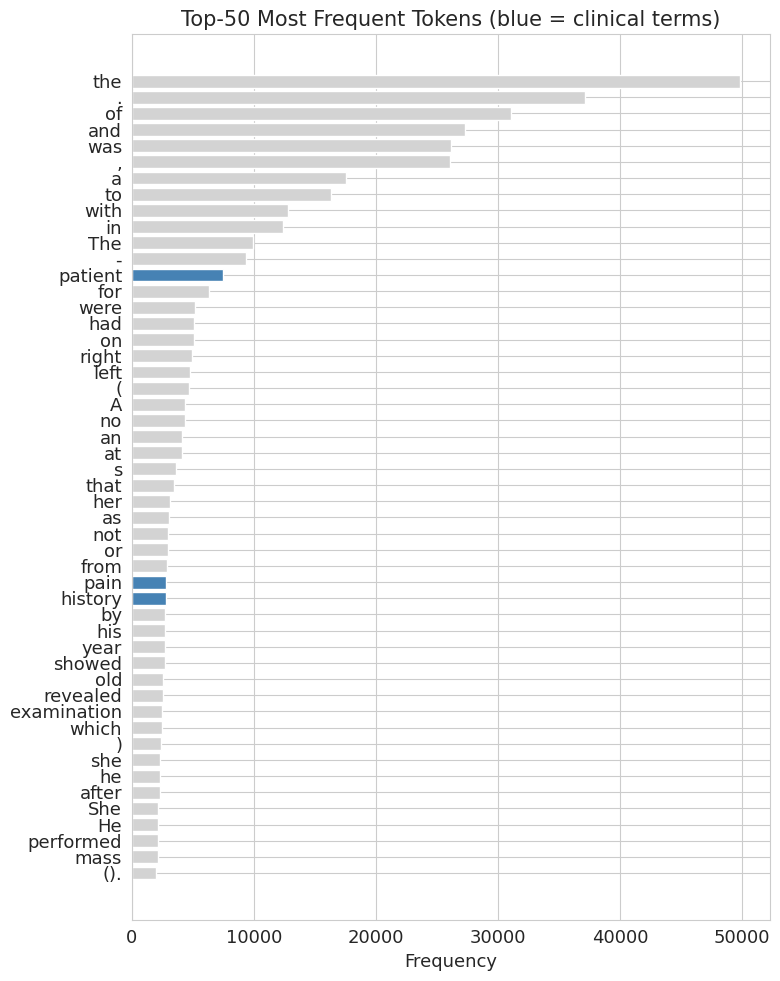

In [15]:
# ── Visualization 5: Token frequency distribution ──
from collections import Counter

token_counter = Counter()
for ex in train_ds:
    tokens = tokenizer.tokenize(ex["note"])
    token_counter.update(tokens)

top50 = token_counter.most_common(50)
tok_labels, tok_freqs = zip(*top50)

# Heuristic: color clinical terms differently
clinical_keywords = {"patient", "diagnosis", "mg", "blood", "heart", "treatment",
                     "pain", "history", "medical", "hospital", "disease", "symptoms",
                     "clinical", "therapy", "surgery", "chronic", "acute", "fever"}
colors = ["steelblue" if t.lower().strip() in clinical_keywords else "lightgray"
          for t in tok_labels]

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(list(reversed(tok_labels)), list(reversed(tok_freqs)),
        color=list(reversed(colors)), edgecolor="white")
ax.set_xlabel("Frequency")
ax.set_title("Top-50 Most Frequent Tokens (blue = clinical terms)")
plt.tight_layout()
plt.show()

### From Tokens to IDs to Embeddings

Once we have token IDs, we look them up in an **embedding table**: a learnable matrix of shape `(vocab_size, n_embd)`.

```
Token: "patient"  →  ID: 42  →  Embedding: [0.12, -0.34, 0.56, ...] (256-dim vector)
```

In PyTorch this is `nn.Embedding(vocab_size, n_embd)` — a simple lookup table. Each row is a learnable vector for one token.

We also add **position embeddings** so the model knows *where* each token appears in the sequence:

$$\text{Model Input} = \text{TokenEmb}(x) + \text{PosEmb}(\text{position})$$

In [16]:
# Demonstrate embedding lookup
import torch.nn as nn

embedding = nn.Embedding(num_embeddings=8000, embedding_dim=256)

phrase = "patient with acute chest pain"
ids = tokenizer.encode(phrase, return_tensors="pt")
emb = embedding(ids)

print(f"Phrase: '{phrase}'")
print(f"Token IDs shape: {ids.shape}")
print(f"Embedding shape: {emb.shape}  (batch, seq_len, n_embd)")
print(f"\nEmbedding table total: {8000} tokens × 256 dims = {8000*256:,} parameters")

Phrase: 'patient with acute chest pain'
Token IDs shape: torch.Size([1, 5])
Embedding shape: torch.Size([1, 5, 256])  (batch, seq_len, n_embd)

Embedding table total: 8000 tokens × 256 dims = 2,048,000 parameters


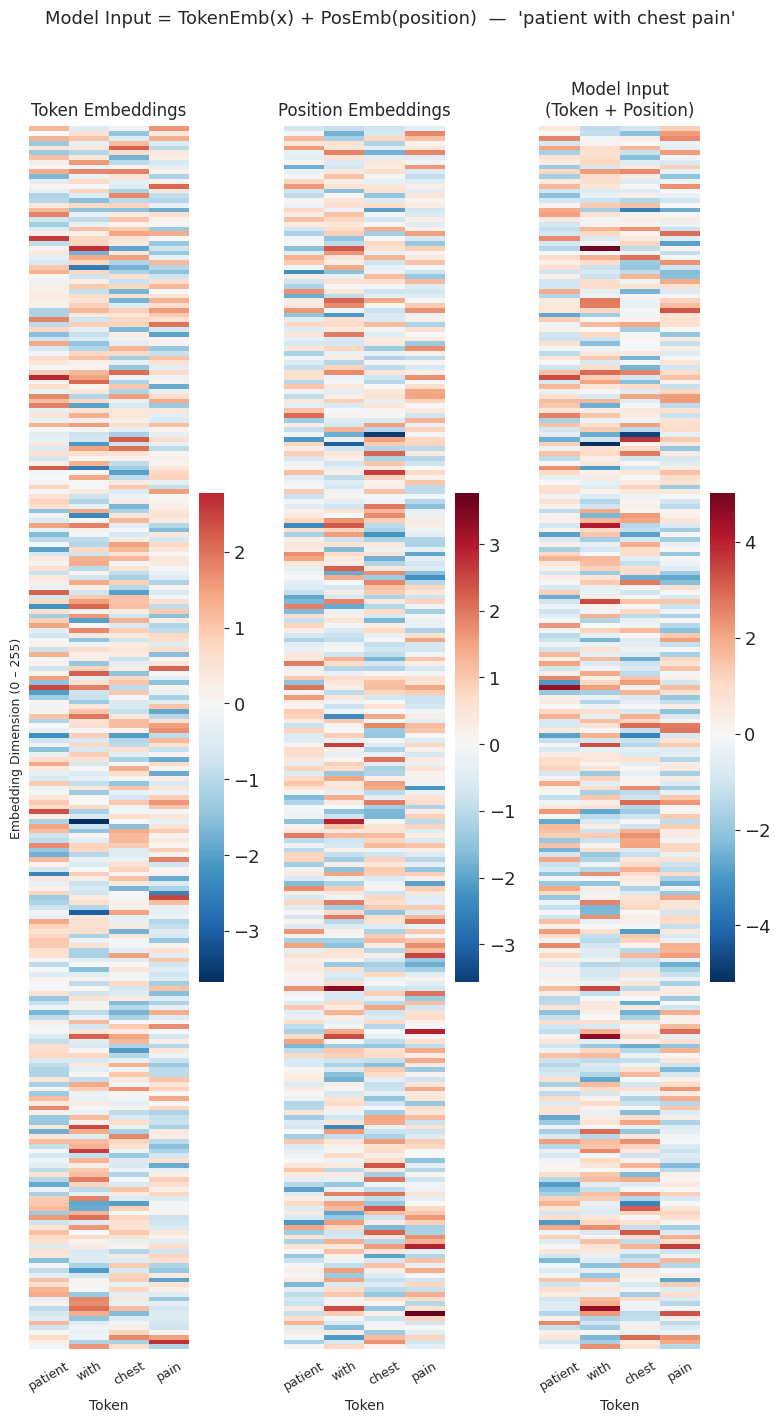

Teaching point: token embeddings encode 'what' each token is; position embeddings encode 'where' it appears.


In [17]:
# ── Visualize: Token Embedding + Position Embedding = Model Input ──
import torch.nn as nn

# Create embedding layers matching our model config
vocab_size, n_embd, n_positions = 8000, 256, 256
tok_emb = nn.Embedding(vocab_size, n_embd)
pos_emb = nn.Embedding(n_positions, n_embd)

# Encode a short clinical phrase
phrase = "patient with chest pain"
input_ids = tokenizer.encode(phrase, return_tensors="pt")
seq_len = input_ids.shape[1]
position_ids = torch.arange(seq_len).unsqueeze(0)

with torch.no_grad():
    token_embeddings = tok_emb(input_ids)[0]        # (seq_len, n_embd)
    position_embeddings = pos_emb(position_ids)[0]  # (seq_len, n_embd)
    model_input = token_embeddings + position_embeddings

tokens_str = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

# Transpose: rows = embedding dims (all 256), columns = tokens
matrices = [
    token_embeddings.T.numpy(),        # (n_embd, seq_len)
    position_embeddings.T.numpy(),
    model_input.T.numpy(),
]
titles = ["Token Embeddings", "Position Embeddings", "Model Input\n(Token + Position)"]

# Narrow row height to show all 256 dims compactly; width scales with token count
row_h = 0.055           # inches per embedding dim
fig_h = max(6, n_embd * row_h)
col_w = max(1.8, seq_len * 0.5)  # inches per subplot
fig_w = col_w * 3 + 2

fig, axes = plt.subplots(1, 3, figsize=(fig_w, fig_h))

for ax, data, title in zip(axes, matrices, titles):
    sns.heatmap(data, ax=ax, cmap="RdBu_r", center=0,
                xticklabels=tokens_str, yticklabels=False,
                cbar_kws={"shrink": 0.4})
    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xlabel("Token", fontsize=10)
    ax.set_ylabel("Embedding Dimension (0 – 255)" if ax is axes[0] else "", fontsize=9)
    ax.tick_params(axis="x", labelsize=9, rotation=30)

fig.suptitle(
    f"Model Input = TokenEmb(x) + PosEmb(position)  —  '{phrase}'",
    fontsize=13, y=1.01
)
plt.tight_layout()
plt.show()
print("Teaching point: token embeddings encode 'what' each token is; position embeddings encode 'where' it appears.")

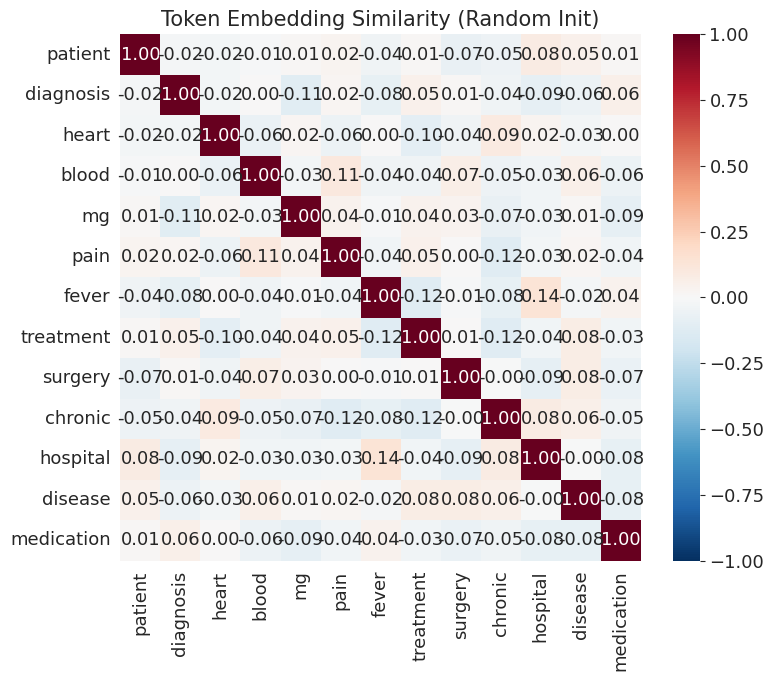

Teaching point: before training, similarities are essentially random. After pretraining, clinically related terms will cluster.


In [18]:
# ── Visualization 6: Embedding similarity heatmap (random init) ──
import torch.nn.functional as F

clinical_terms = ["patient", "diagnosis", "heart", "blood", "mg",
                  "pain", "fever", "treatment", "surgery", "chronic",
                  "hospital", "disease", "medication"]

term_ids = [tokenizer.encode(t)[0] for t in clinical_terms
            if len(tokenizer.encode(t)) > 0]
term_labels = [clinical_terms[i] for i in range(len(clinical_terms))
               if len(tokenizer.encode(clinical_terms[i])) > 0]

with torch.no_grad():
    term_embs = embedding(torch.tensor(term_ids))
    # Cosine similarity
    normed = F.normalize(term_embs, dim=1)
    sim_matrix = (normed @ normed.T).numpy()

plt.figure(figsize=(8, 7))
sns.heatmap(sim_matrix, xticklabels=term_labels, yticklabels=term_labels,
            annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1)
plt.title("Token Embedding Similarity (Random Init)")
plt.tight_layout()
plt.show()
print("Teaching point: before training, similarities are essentially random. After pretraining, clinically related terms will cluster.")

<a id="attention"></a>

---
## Section 3: Attention and the Tiny Transformer

### The Attention Mechanism

The core idea: each token should *attend* to other tokens to build context-aware representations.

Given input $X \in \mathbb{R}^{n \times d}$, we project into **queries**, **keys**, and **values**:

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

The attention output:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Multi-head attention** runs $h$ parallel attention heads and concatenates:

$$\text{MultiHead}(X) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)W^O$$

Each head can attend to different aspects of the input — syntax, semantics, coreference.

### Our Tiny GPT Architecture

```
Input IDs → Token Emb + Position Emb
     ↓
[Transformer Block × 4]
  ├─ Masked Multi-Head Attention (4 heads)
  ├─ LayerNorm + Residual
  ├─ FFN (256 → 1024 → 256)
  └─ LayerNorm + Residual
     ↓
LM Head → logits over vocab (8000)
```

This is intentionally tiny (~5M params) so it trains in minutes on a T4. The point is **visibility into each component**, not performance.

In [19]:
# Build our tiny clinical GPT
from transformers import GPT2Config, GPT2LMHeadModel

config = GPT2Config(
    vocab_size=len(tokenizer),
    n_positions=256,
    n_embd=256,
    n_layer=4,
    n_head=4,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
)

# Use "eager" attention so output_attentions=True returns actual weight matrices.
# The default "sdpa" backend uses fused kernels that cannot return attention matrices.
config._attn_implementation = "eager"

model = GPT2LMHeadModel(config)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")
print(f"\nConfig: vocab={config.vocab_size}, n_positions={config.n_positions}, "
      f"n_embd={config.n_embd}, n_layer={config.n_layer}, n_head={config.n_head}")

Total parameters: 5,273,088

Config: vocab=8000, n_positions=256, n_embd=256, n_layer=4, n_head=4


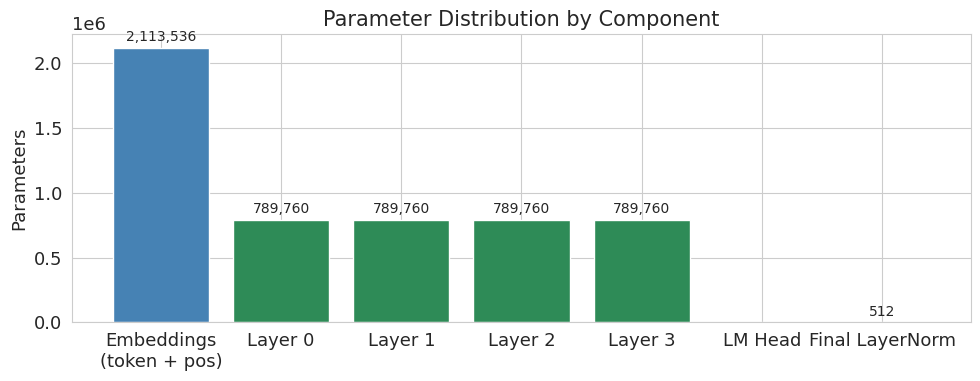

Teaching point: even in a tiny model, the embedding table is a large fraction of total parameters.


In [20]:
# ── Visualization 7: Parameter distribution ──
param_counts = {}

# Token + position embeddings
emb_params = sum(p.numel() for n, p in model.named_parameters() if "wte" in n or "wpe" in n)
param_counts["Embeddings\n(token + pos)"] = emb_params

# Each transformer layer
for i in range(config.n_layer):
    layer_params = sum(p.numel() for n, p in model.named_parameters() if f".h.{i}." in n)
    param_counts[f"Layer {i}"] = layer_params

# LM head (tied with embeddings in GPT-2, but count for illustration)
lm_head_params = sum(p.numel() for n, p in model.named_parameters() if "lm_head" in n)
param_counts["LM Head"] = lm_head_params if lm_head_params > 0 else 0
# LayerNorm final
ln_params = sum(p.numel() for n, p in model.named_parameters() if "ln_f" in n)
param_counts["Final LayerNorm"] = ln_params

labels = list(param_counts.keys())
values = list(param_counts.values())
colors_bar = ["steelblue"] + ["seagreen"] * config.n_layer + ["coral", "gray"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, values, color=colors_bar[:len(labels)], edgecolor="white")
ax.set_ylabel("Parameters")
ax.set_title("Parameter Distribution by Component")
for bar, v in zip(bars, values):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, v + total_params*0.01,
                f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()
print("Teaching point: even in a tiny model, the embedding table is a large fraction of total parameters.")

In [21]:
# Forward pass with attention outputs
sample_text = "The patient presented with chest pain and shortness of breath"
inputs = tokenizer(sample_text, return_tensors="pt").to(device)

model.eval()
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True)

print(f"Number of layers: {len(outputs.attentions)}")
print(f"Attention shape per layer: {outputs.attentions[0].shape}")
print(f"  → (batch, heads, seq_len, seq_len)")

Number of layers: 4
Attention shape per layer: torch.Size([1, 4, 10, 10])
  → (batch, heads, seq_len, seq_len)


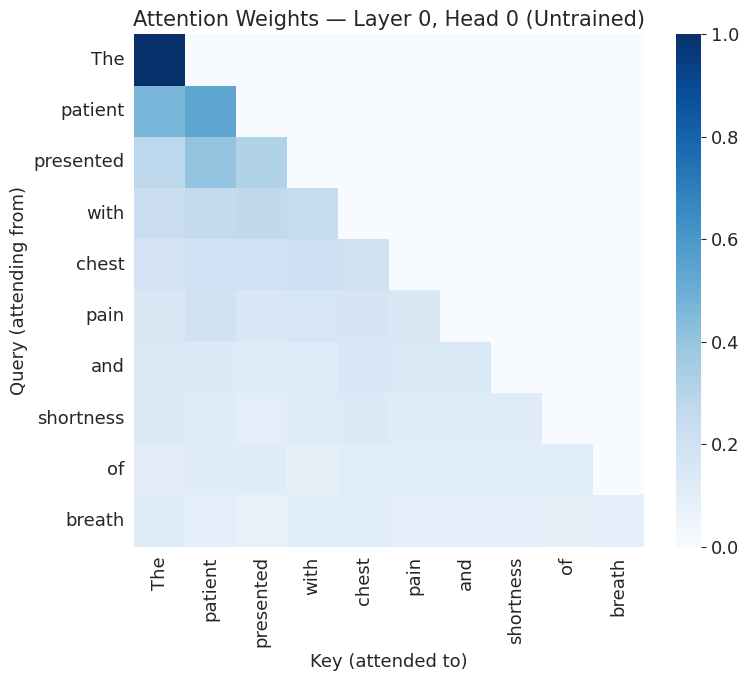

Teaching point: the causal mask is visible (upper triangle is zero). Attention is roughly uniform before training.


In [22]:
# ── Visualization 8: Attention heatmap (untrained, single head) ──
attn = outputs.attentions[0][0, 0].cpu().numpy()  # layer 0, head 0
tokens_for_plot = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0].tolist())

plt.figure(figsize=(8, 7))
sns.heatmap(attn, xticklabels=tokens_for_plot, yticklabels=tokens_for_plot,
            cmap="Blues", vmin=0, vmax=1)
plt.title("Attention Weights — Layer 0, Head 0 (Untrained)")
plt.xlabel("Key (attended to)")
plt.ylabel("Query (attending from)")
plt.tight_layout()
plt.show()
print("Teaching point: the causal mask is visible (upper triangle is zero). Attention is roughly uniform before training.")

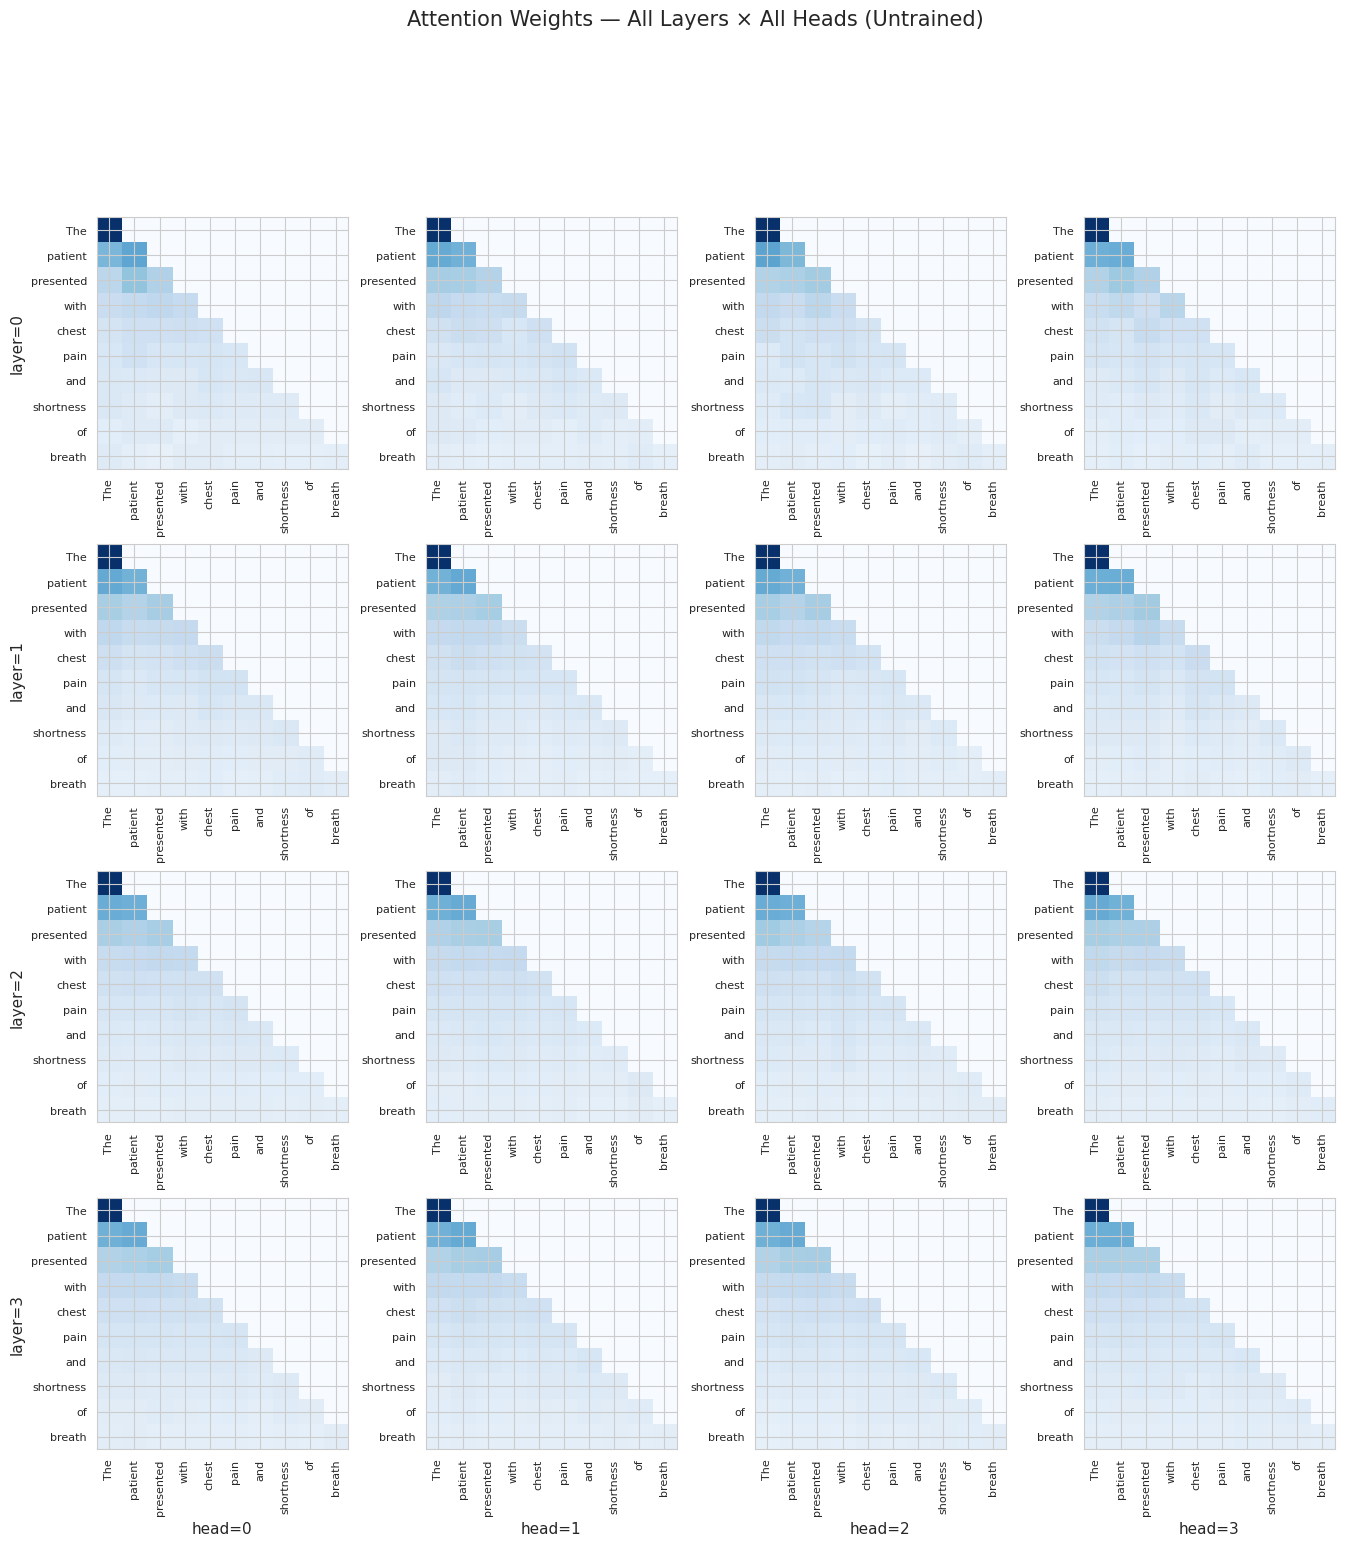

Grid: 4 layers × 4 heads. Causal mask visible (upper triangle = 0).


In [23]:
# ── Visualization 9: All layers × all heads attention grid (untrained) ──
n_layers = len(outputs.attentions)
n_heads = outputs.attentions[0].shape[1]

fig, axes = plt.subplots(n_layers, n_heads, figsize=(4 * n_heads, 4 * n_layers))
fig.set_size_inches(4 * n_heads, 4 * n_layers)

for layer in range(n_layers):
    for head in range(n_heads):
        ax = axes[layer, head] if n_layers > 1 else axes[head]
        attn_data = outputs.attentions[layer][0, head].cpu().numpy()
        ax.imshow(attn_data, cmap="Blues", vmin=0, vmax=1)
        ax.set_xticks(range(len(tokens_for_plot)))
        ax.set_xticklabels(tokens_for_plot, rotation=90, fontsize=8)
        ax.set_yticks(range(len(tokens_for_plot)))
        ax.set_yticklabels(tokens_for_plot, fontsize=8)

        if layer == n_layers - 1:
            ax.set_xlabel(f"head={head}", fontsize=11)
        if head == 0:
            ax.set_ylabel(f"layer={layer}", fontsize=11)

plt.suptitle("Attention Weights — All Layers × All Heads (Untrained)", fontsize=15, y=1.01)
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()
print(f"Grid: {n_layers} layers × {n_heads} heads. Causal mask visible (upper triangle = 0).")

In [24]:
# ── BertViz: Interactive attention visualization ──
try:
    pip_install(["bertviz"])
    from bertviz import head_view

    # BertViz expects attention as a tuple of tensors: (n_layers,) each (batch, heads, seq, seq)
    attention = tuple(a.cpu() for a in outputs.attentions)

    print("BertViz interactive head view (select layers/heads in the widget):")
    head_view(attention, tokens_for_plot)
except Exception as e:
    print(f"BertViz not available (optional): {e}")
    print("Install with: pip install bertviz")

BertViz interactive head view (select layers/heads in the widget):


<IPython.core.display.Javascript object>

In [25]:
# Generate from the untrained model — expect random gibberish
untrained_output = generate_text(model, tokenizer, "The patient presented with", max_new_tokens=60)
print("Untrained model output:")
print("-" * 40)
print(untrained_output)
print("-" * 40)
print("\nThe model has architecture but no knowledge — just random weights.")

Untrained model output:
----------------------------------------
ones 57 Diagn Radiographic Loss mainly tivity tives TS p TS described months concern Subcutaneous diffic Gi proced neurof vember fasc aund sure Increas risk utation to thyroid axis Fa Increas ised incisors neighbor Venous introduced sec partum red indic Aggravated therefore respectively ves embed cessive ending placent consciousness diffusion ks Transferred impossible worse 59 trectomy Family atch Increas dura
----------------------------------------

The model has architecture but no knowledge — just random weights.


<a id="pretraining"></a>

---
## Section 4: Pretraining by Next-Token Prediction

**Pretraining** teaches the model the statistical patterns of clinical language. The objective is simple: given tokens $[t_1, \ldots, t_n]$, predict $[t_2, \ldots, t_{n+1}]$.

The loss is **cross-entropy** between the predicted and actual next token at each position:

$$\mathcal{L} = -\frac{1}{n}\sum_{i=1}^{n} \log P(t_{i+1} \mid t_1, \ldots, t_i)$$

The causal mask ensures the model only uses **left context** — it cannot cheat by looking ahead.

In [26]:
# Prepare pretraining dataset: tokenize, concatenate, chunk into blocks of 256
from transformers import DataCollatorForLanguageModeling

BLOCK_SIZE = 256

def tokenize_and_chunk(examples):
    # Tokenize all notes
    tokenized = tokenizer(examples["note"], truncation=False)
    # Concatenate all token IDs
    all_ids = []
    for ids in tokenized["input_ids"]:
        all_ids.extend(ids)
    # Chunk into blocks
    chunks = [all_ids[i : i + BLOCK_SIZE] for i in range(0, len(all_ids) - BLOCK_SIZE, BLOCK_SIZE)]
    return {"input_ids": chunks}

pretrain_dataset = train_ds.map(
    tokenize_and_chunk, batched=True, remove_columns=train_ds.column_names,
    batch_size=len(train_ds), num_proc=1,
)
pretrain_dataset.set_format("torch")

# Also create a validation pretraining dataset for test loss monitoring
pretrain_val_dataset = val_ds.map(
    tokenize_and_chunk, batched=True, remove_columns=val_ds.column_names,
    batch_size=len(val_ds), num_proc=1,
)
pretrain_val_dataset.set_format("torch")

data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

print(f"Pretraining chunks: {len(pretrain_dataset)} train, {len(pretrain_val_dataset)} val (each {BLOCK_SIZE} tokens)")

Pretraining chunks: 3847 train, 480 val (each 256 tokens)


In [27]:
# Configure Trainer
from transformers import Trainer, TrainingArguments

use_fp16 = torch.cuda.is_available()

pretrain_args = TrainingArguments(
    output_dir="pretrained_clinical_gpt",
    max_steps=500,
    per_device_train_batch_size=8,
    learning_rate=5e-4,
    warmup_steps=100,
    logging_steps=10,
    eval_steps=50,
    eval_strategy="steps",
    fp16=use_fp16,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

In [28]:
# Train or load checkpoint
import os

if not USE_PRECOMPUTED:
    pretrain_trainer = Trainer(
        model=model,
        args=pretrain_args,
        train_dataset=pretrain_dataset,
        eval_dataset=pretrain_val_dataset,
        data_collator=data_collator,
    )
    pretrain_trainer.train()
    model.save_pretrained("pretrained_clinical_gpt")
    tokenizer.save_pretrained("pretrained_clinical_gpt")
    pretrain_log = pretrain_trainer.state.log_history
    print("Pretraining complete!")
else:
    ckpt_path = os.path.join(CHECKPOINT_DIR, "pretrained")
    model = GPT2LMHeadModel.from_pretrained(ckpt_path, attn_implementation="eager").to(device)
    pretrain_log = []  # No log when loading checkpoint
    print(f"Loaded pretrained model from {ckpt_path}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss,Validation Loss
50,7.574357,7.342684
100,6.418921,6.358248
150,5.991564,5.941749
200,5.743764,5.697074
250,5.531317,5.560432
300,5.502348,5.462031
350,5.400709,5.393703
400,5.351936,5.343508
450,5.418704,5.313554
500,5.229208,5.300409


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Pretraining complete!


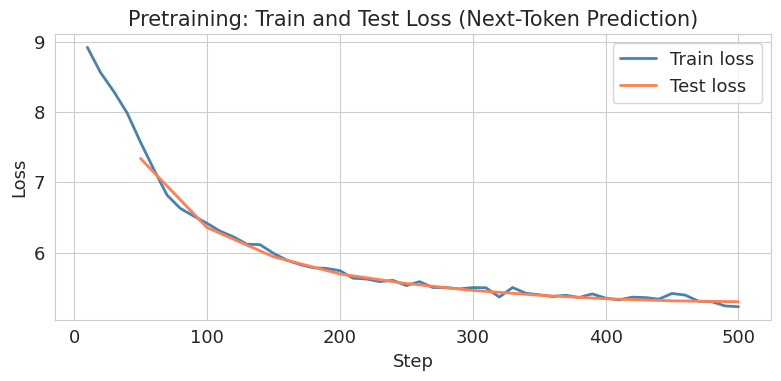

Rapid initial drop (learning basic patterns), then slower improvement.


In [29]:
# ── Visualization 10: Pretraining train and test loss curve ──
if pretrain_log:
    plot_train_eval_curves(
        pretrain_log,
        train_metric="loss",
        eval_metric="eval_loss",
        title="Pretraining: Train and Test Loss (Next-Token Prediction)",
        eval_label="Test loss",
    )
    print("Rapid initial drop (learning basic patterns), then slower improvement.")
else:
    print("(No training log — loaded from checkpoint)")

In [30]:
# Generate from the pretrained model
pretrained_prompts = [
    "The patient presented with",
    "Diagnosis: acute",
    "Treatment plan includes",
]

print("=" * 60)
print("PRETRAINED MODEL OUTPUTS")
print("=" * 60)
pretrained_outputs = {}
for prompt in pretrained_prompts:
    output = generate_text(model, tokenizer, prompt, max_new_tokens=80)
    pretrained_outputs[prompt] = output
    print(f"\nPrompt: '{prompt}'")
    print(f"Output: {output}")
    print("-" * 40)

PRETRAINED MODEL OUTPUTS

Prompt: 'The patient presented with'
Output: an family history of a small body , and there was also had a history of a 2 years ago . The patient developed increased and a history of motion with a history of the patient presented with significant medical history of the patient had a history of a history of the right temporal head and she was performed . The distal femoral vein and had a history of the left ventricular and a signs of the patient was started
----------------------------------------

Prompt: 'Diagnosis: acute'
Output: - old female presented to be in the last hospital . The patient was a medical history of the patient underwent a history of the patient was obtained . The patient underwent chronic medical history of the patient was a history of a medical history of a history of pain . The patient presented to the right lower limb . There was a history of the patient was started to the patient was no evidence of her right leg .
----------------------

In [31]:
# ── Visualization 11: Before vs after pretraining ──
rows = []
for prompt in pretrained_prompts:
    rows.append([prompt, "(random gibberish)", pretrained_outputs[prompt][:200]])

display_comparison_table(
    rows,
    columns=["Prompt", "Untrained Output", "Pretrained Output"],
    title="Before vs After Pretraining"
)
print("Teaching point: the model now produces clinical-sounding text. It learned language patterns from the notes.")

Prompt,Untrained Output,Pretrained Output
The patient presented with,(random gibberish),"an family history of a small body , and there was also had a history of a 2 years ago . The patient developed increased and a history of motion with a history of the patient presented with significant"
Diagnosis: acute,(random gibberish),- old female presented to be in the last hospital . The patient was a medical history of the patient underwent a history of the patient was obtained . The patient underwent chronic medical history of
Treatment plan includes,(random gibberish),to a history of a medical history of the swelling on the patient in the patient was normal . On the patient was performed at the patient was referred to the left hip and the patient was no medical his


Teaching point: the model now produces clinical-sounding text. It learned language patterns from the notes.


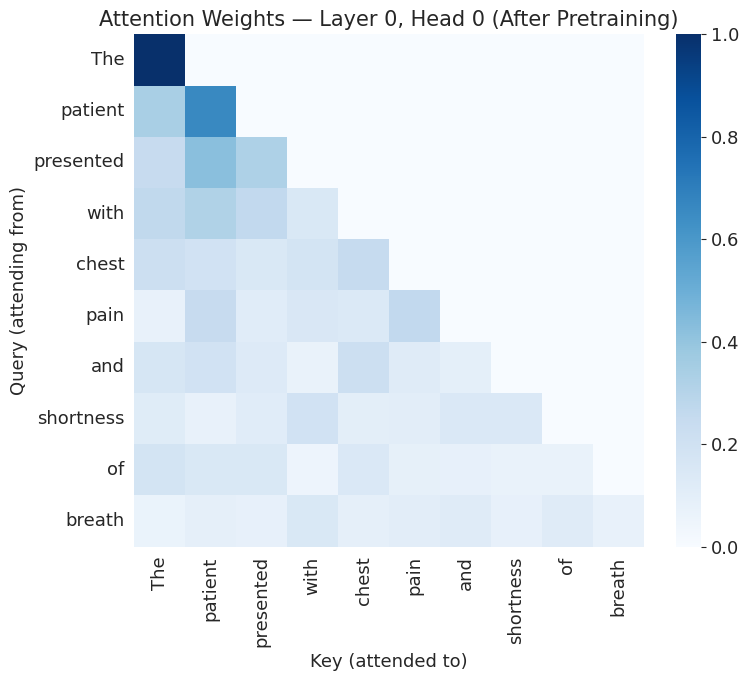

Teaching point: attention patterns are now structured — some positions attend strongly to specific terms.


In [32]:
# ── Visualization 12: Attention heatmap after pretraining ──
model.eval()
inputs = tokenizer(sample_text, return_tensors="pt").to(device)
with torch.no_grad():
    outputs_pt = model(**inputs, output_attentions=True)

attn_pt = outputs_pt.attentions[0][0, 0].cpu().numpy()

plt.figure(figsize=(8, 7))
sns.heatmap(attn_pt, xticklabels=tokens_for_plot, yticklabels=tokens_for_plot,
            cmap="Blues", vmin=0, vmax=1)
plt.title("Attention Weights — Layer 0, Head 0 (After Pretraining)")
plt.xlabel("Key (attended to)")
plt.ylabel("Query (attending from)")
plt.tight_layout()
plt.show()
print("Teaching point: attention patterns are now structured — some positions attend strongly to specific terms.")

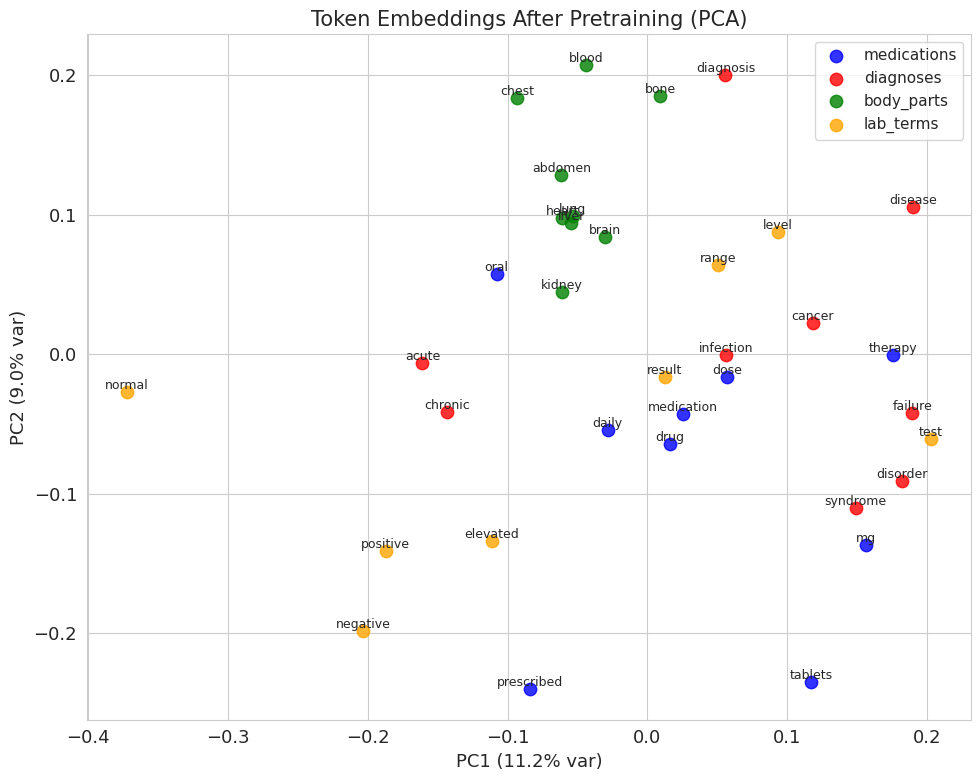

Teaching point: clinically related terms tend to cluster — the model learned semantic relationships.


In [33]:
# ── Visualization 13: Embedding space after pretraining (PCA via SVD) ──

# Collect a set of clinical tokens and their categories
token_categories = {
    "medications": ["mg", "daily", "dose", "medication", "drug", "tablets", "oral",
                    "prescribed", "therapy"],
    "diagnoses": ["diagnosis", "disease", "syndrome", "infection", "chronic",
                  "acute", "cancer", "failure", "disorder"],
    "body_parts": ["heart", "lung", "liver", "kidney", "brain", "blood",
                   "chest", "abdomen", "bone"],
    "lab_terms": ["level", "test", "result", "normal", "elevated",
                  "positive", "negative", "range"],
}

category_colors = {
    "medications": "blue",
    "diagnoses": "red",
    "body_parts": "green",
    "lab_terms": "orange",
}

# Get embeddings from the trained model
wte = model.transformer.wte.weight.detach().cpu()

plot_tokens, plot_embeds, plot_colors, plot_cats = [], [], [], []
for cat, terms in token_categories.items():
    for term in terms:
        ids = tokenizer.encode(term)
        if len(ids) >= 1:
            plot_tokens.append(term)
            plot_embeds.append(wte[ids[0]].numpy())
            plot_colors.append(category_colors[cat])
            plot_cats.append(cat)

if len(plot_embeds) >= 4:
    embeds_np = np.stack(plot_embeds)
    # PCA via SVD (no sklearn needed)
    centered = embeds_np - embeds_np.mean(axis=0)
    U, S, Vt = np.linalg.svd(centered, full_matrices=False)
    coords = centered @ Vt[:2].T
    explained_var = (S[:2] ** 2) / (S ** 2).sum()

    plt.figure(figsize=(10, 8))
    for cat, color in category_colors.items():
        mask = [c == cat for c in plot_cats]
        pts = coords[mask]
        if len(pts) > 0:
            plt.scatter(pts[:, 0], pts[:, 1], c=color, s=80, label=cat, alpha=0.8)

    for i, token in enumerate(plot_tokens):
        plt.annotate(token, (coords[i, 0], coords[i, 1]),
                     fontsize=9, ha="center", va="bottom")

    plt.legend(fontsize=11)
    plt.title("Token Embeddings After Pretraining (PCA)")
    plt.xlabel(f"PC1 ({explained_var[0]:.1%} var)")
    plt.ylabel(f"PC2 ({explained_var[1]:.1%} var)")
    plt.tight_layout()
    plt.show()
    print("Teaching point: clinically related terms tend to cluster — the model learned semantic relationships.")
else:
    print("Not enough tokens resolved for PCA visualization.")

<a id="sft"></a>

---
## Section 5: SFT on Structured Extraction

Pretraining teaches the model to *continue* clinical text. But we want it to *follow instructions* and produce **structured JSON output**.

**Supervised Fine-Tuning (SFT)** trains on prompt-completion pairs:
- **Prompt:** "Convert this clinical note into JSON...\n{note}"
- **Completion:** the gold `summary` JSON

TRL's `SFTTrainer` computes loss **only on the completion** — the model learns to produce the right output given the instruction, without wasting gradient on the prompt itself.

In [34]:
# Prepare prompt-completion dataset for SFT
# Our model only supports 256 positions. We truncate the clinical note so
# prompt + completion together fit within 256 tokens, leaving room for the
# completion (where the loss is actually computed).
MAX_PROMPT_TOKENS = 100  # reserve ~156 tokens for the completion

def to_sft(ex):
    instruction = "Convert the following clinical note into a structured JSON medical record.\n\nClinical note:\n"
    suffix = "\n\nJSON:\n"
    # Truncate the note to fit within the prompt budget
    instr_len = len(tokenizer.encode(instruction + suffix))
    max_note_tokens = MAX_PROMPT_TOKENS - instr_len
    note_ids = tokenizer.encode(ex["note"], add_special_tokens=False)
    if len(note_ids) > max_note_tokens:
        note_ids = note_ids[:max_note_tokens]
    truncated_note = tokenizer.decode(note_ids)
    prompt = instruction + truncated_note + suffix
    return {"prompt": prompt, "completion": ex["summary"]}

sft_train = train_ds.map(to_sft, remove_columns=train_ds.column_names)
sft_val = val_ds.map(to_sft, remove_columns=val_ds.column_names)
sft_test = test_ds.map(to_sft, remove_columns=test_ds.column_names)

print(f"SFT train examples: {len(sft_train)}")
print(f"SFT val examples:   {len(sft_val)}")
print(f"SFT test examples:  {len(sft_test)}")
print(f"\nExample prompt (first 200 chars):\n{sft_train[0]['prompt'][:200]}...")
print(f"\nExample completion (first 200 chars):\n{sft_train[0]['completion'][:200]}...")

SFT train examples: 2400
SFT val examples:   300
SFT test examples:  300

Example prompt (first 200 chars):
Convert the following clinical note into a structured JSON medical record.

Clinical note:
A 60 - year - old man presented with a 16 × 6 cm2 open wound with an ac company ing tib i of ibular fracture ...

Example completion (first 200 chars):
{
"visit motivation": "Open wound and tibiofibular fracture due to a traffic accident",
"admission": [
{
"reason": "To receive free flap coverage for the open wound and tibiofibular fracture",
"date":...


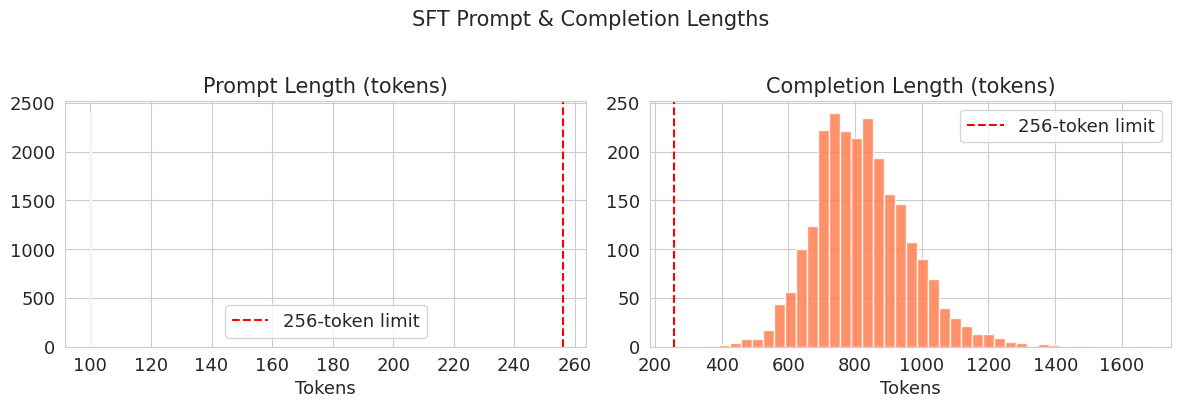

Note: some examples exceed our 256-token limit and will be truncated.


In [35]:
# ── Visualization 14: Prompt/completion length distribution ──
prompt_lens = [len(tokenizer.encode(ex["prompt"])) for ex in sft_train]
completion_lens = [len(tokenizer.encode(ex["completion"])) for ex in sft_train]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(prompt_lens, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax1.axvline(256, color="red", linestyle="--", label="256-token limit")
ax1.set_title("Prompt Length (tokens)")
ax1.set_xlabel("Tokens")
ax1.legend()

ax2.hist(completion_lens, bins=40, color="coral", edgecolor="white", alpha=0.85)
ax2.axvline(256, color="red", linestyle="--", label="256-token limit")
ax2.set_title("Completion Length (tokens)")
ax2.set_xlabel("Tokens")
ax2.legend()

plt.suptitle("SFT Prompt & Completion Lengths", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()
print("Note: some examples exceed our 256-token limit and will be truncated.")

In [36]:
# Configure SFTTrainer
import inspect
from trl import SFTTrainer, SFTConfig

# Save pretrained model for comparison later
pretrained_model_state = {k: v.clone() for k, v in model.state_dict().items()}

use_fp16 = torch.cuda.is_available()

sft_config_kwargs = dict(
    output_dir="sft_clinical_gpt",
    max_steps=300,
    per_device_train_batch_size=4,
    learning_rate=2e-4,
    warmup_steps=50,
    logging_steps=10,
    fp16=use_fp16,
    gradient_checkpointing=False,  # avoid CheckpointError with GPT-2 eager attention
    save_strategy="no",
    report_to="none",
    seed=SEED,
    eval_steps=10,
    # For teaching, we monitor held-out test loss during training.
    # In a production workflow, prefer validation loss for model selection.
)

# Use the correct truncation param name for this TRL version
# Must match model's n_positions=256
sft_config_params = inspect.signature(SFTConfig.__init__).parameters
if "max_seq_length" in sft_config_params:
    sft_config_kwargs["max_seq_length"] = 256
elif "max_length" in sft_config_params:
    sft_config_kwargs["max_length"] = 256

if "eval_strategy" in sft_config_params:
    sft_config_kwargs["eval_strategy"] = "steps"
else:
    sft_config_kwargs["evaluation_strategy"] = "steps"

sft_config = SFTConfig(**sft_config_kwargs)

In [37]:
# Train SFT or load checkpoint, then measure held-out test loss
if USE_PRECOMPUTED:
    ckpt_path = os.path.join(CHECKPOINT_DIR, "sft")
    model = GPT2LMHeadModel.from_pretrained(ckpt_path, attn_implementation="eager").to(device)
    print(f"Loaded SFT model from {ckpt_path}")

# Use inspect.signature to handle tokenizer vs processing_class compatibility
sft_kwargs = dict(
    model=model,
    train_dataset=sft_train,
    eval_dataset=sft_test,
    args=sft_config,
)
params = inspect.signature(SFTTrainer.__init__).parameters
if "tokenizer" in params:
    sft_kwargs["tokenizer"] = tokenizer
elif "processing_class" in params:
    sft_kwargs["processing_class"] = tokenizer

sft_trainer = SFTTrainer(**sft_kwargs)

if not USE_PRECOMPUTED:
    sft_trainer.train()
    model.save_pretrained("sft_clinical_gpt")
    tokenizer.save_pretrained("sft_clinical_gpt")
    sft_log = sft_trainer.state.log_history
    print("SFT complete!")
else:
    sft_log = []

# Extract held-out test loss from the last eval entry in the training log,
# or compute it manually for the precomputed path.
# (Calling sft_trainer.evaluate() after train() triggers a callback state error
#  in newer transformers.)
sft_test_loss = None
if sft_log:
    eval_entries = [e for e in sft_log if "eval_loss" in e]
    if eval_entries:
        sft_test_loss = eval_entries[-1]["eval_loss"]
if sft_test_loss is None:
    # Manual evaluation for precomputed or if no eval entries in log
    model.eval()
    eval_dataloader = sft_trainer.get_eval_dataloader()
    total_loss, total_steps = 0.0, 0
    with torch.no_grad():
        for batch in eval_dataloader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            if outputs.loss is not None:
                total_loss += outputs.loss.item()
                total_steps += 1
    sft_test_loss = total_loss / total_steps if total_steps > 0 else float("nan")

print(f"Held-out test loss: {sft_test_loss:.4f}")

Adding EOS to train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2400 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/300 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
10,10.185128,9.367090
20,8.618536,7.622975
30,7.109645,6.419874
40,6.067432,5.507651
50,5.307983,4.696334
60,4.523433,4.049673
70,3.829775,3.542692
80,3.392130,3.146924
90,3.037418,2.850987
100,2.806542,2.635290


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

SFT complete!
Held-out test loss: 1.9902


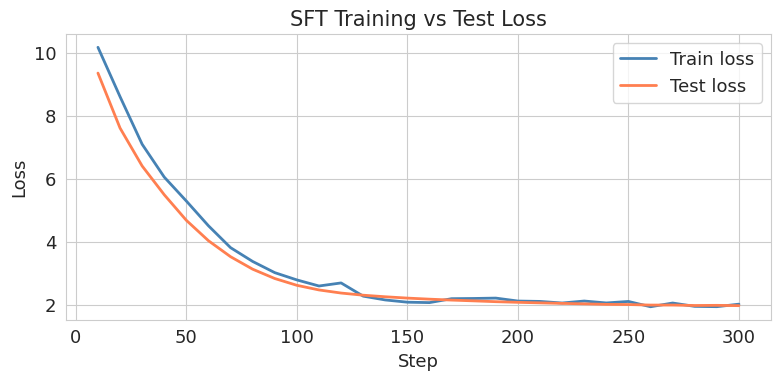

Final held-out test loss: 1.9902


In [38]:
# ── Visualization 15: SFT training and test loss curves ──
if sft_log:
    plot_train_eval_curves(
        sft_log,
        train_metric="loss",
        eval_metric="eval_loss",
        title="SFT Training vs Test Loss",
        eval_label="Test loss",
    )
else:
    print("(No training log — loaded from checkpoint)")

if sft_test_loss is not None:
    print(f"Final held-out test loss: {sft_test_loss:.4f}")

In [39]:
# Generate JSON outputs on test examples
sft_model = model  # alias for clarity

n_test_examples = 5
test_prompts = [to_sft(test_ds[i])["prompt"] for i in range(n_test_examples)]
test_golds   = [test_ds[i]["summary"] for i in range(n_test_examples)]

sft_outputs = []
for prompt in test_prompts:
    out = generate_text(sft_model, tokenizer, prompt, max_new_tokens=128, temperature=0.3)
    sft_outputs.append(out)

for i in range(n_test_examples):
    print(f"\n{'='*60}")
    print(f"Test example {i+1}")
    print(f"SFT output (first 300 chars):\n{sft_outputs[i][:300]}")
    print(f"\nGold (first 300 chars):\n{test_golds[i][:300]}")


Test example 1
SFT output (first 300 chars):
{ " visit motivation ": " None ", " admission ": " admission ": [ { " admission ": " None ", " None ", " None ", " care center details ": " care center details ": " None ", " care center details ": " None " age ": " patient information ": " patient information ": " None ", " None " patient informati

Gold (first 300 chars):
{
"visit motivation": "Fetal cardiac mass",
"admission": [
{
"reason": "Fetal cardiac mass and associated complications",
"date": "None",
"duration": "5 days",
"care center details": "None"
}
],
"patient information": {
"age": "32 years old",
"sex": "Female",
"ethnicity": "None",
"weight": "None",
"

Test example 2
SFT output (first 300 chars):
{ " visit motivation ": " { " admission ": " reason ": " None ", " reason ": " None ", " None ", " None ", " None ", " care center details ": " None " patient information ": " None " None " patient information ": " patient medical history ": " patient information ": " patient medi

In [40]:
# Evaluation functions
def is_valid_json(text):
    """Check if text is valid JSON."""
    try:
        json.loads(text)
        return True
    except (json.JSONDecodeError, TypeError):
        return False

def schema_compliance(text, gold_text):
    """Fraction of gold top-level keys present in the output."""
    try:
        pred = json.loads(text)
        gold = json.loads(gold_text)
        if not isinstance(pred, dict) or not isinstance(gold, dict):
            return 0.0
        gold_keys = set(gold.keys())
        if len(gold_keys) == 0:
            return 1.0
        return len(set(pred.keys()) & gold_keys) / len(gold_keys)
    except (json.JSONDecodeError, TypeError):
        return 0.0

def reference_overlap(text, gold_text):
    """Jaccard-like overlap of parsed key-value pairs."""
    try:
        pred = json.loads(text)
        gold = json.loads(gold_text)
        if not isinstance(pred, dict) or not isinstance(gold, dict):
            return 0.0
        pred_items = set((str(k), str(v)) for k, v in pred.items())
        gold_items = set((str(k), str(v)) for k, v in gold.items())
        if len(gold_items) == 0:
            return 1.0
        intersection = pred_items & gold_items
        union = pred_items | gold_items
        return len(intersection) / len(union) if union else 0.0
    except (json.JSONDecodeError, TypeError):
        return 0.0

# Evaluate SFT model on test set
n_eval = min(50, len(test_ds))
sft_json_valid, sft_schema, sft_overlap = [], [], []

for i in range(n_eval):
    prompt = to_sft(test_ds[i])["prompt"]
    gold = test_ds[i]["summary"]
    out = generate_text(sft_model, tokenizer, prompt, max_new_tokens=128, temperature=0.3)
    sft_json_valid.append(is_valid_json(out))
    sft_schema.append(schema_compliance(out, gold))
    sft_overlap.append(reference_overlap(out, gold))

print(f"SFT Evaluation ({n_eval} examples):")
print(f"  JSON validity: {np.mean(sft_json_valid):.1%}")
print(f"  Schema compliance: {np.mean(sft_schema):.1%}")
print(f"  Reference overlap: {np.mean(sft_overlap):.1%}")

SFT Evaluation (50 examples):
  JSON validity: 0.0%
  Schema compliance: 0.0%
  Reference overlap: 0.0%


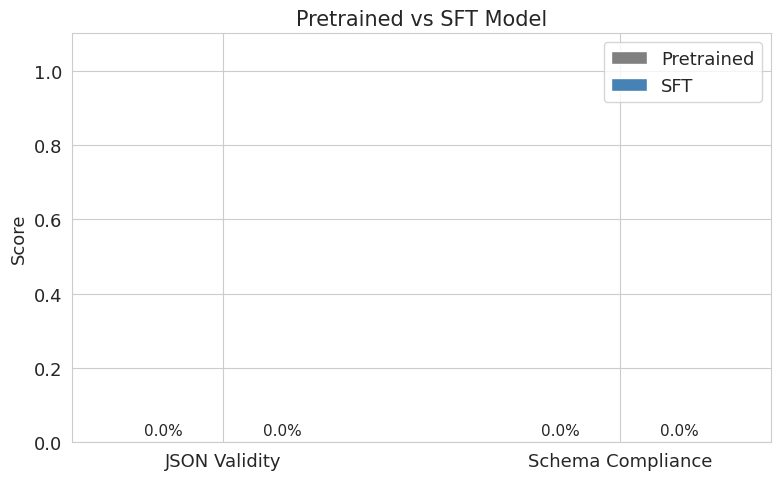

Teaching point: SFT dramatically improves structured output — the model learned to follow the instruction.


In [41]:
# ── Visualization 16: JSON validity & schema compliance ──
# Also evaluate pretrained model for comparison
pretrained_for_eval = GPT2LMHeadModel(config).to(device)
pretrained_for_eval.load_state_dict(pretrained_model_state)

pt_json_valid, pt_schema = [], []
for i in range(n_eval):
    prompt = to_sft(test_ds[i])["prompt"]
    gold = test_ds[i]["summary"]
    out = generate_text(pretrained_for_eval, tokenizer, prompt, max_new_tokens=128, temperature=0.3)
    pt_json_valid.append(is_valid_json(out))
    pt_schema.append(schema_compliance(out, gold))

metrics = ["JSON Validity", "Schema Compliance"]
pt_vals = [np.mean(pt_json_valid), np.mean(pt_schema)]
sft_vals = [np.mean(sft_json_valid), np.mean(sft_schema)]

x = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, pt_vals, width, label="Pretrained", color="gray", edgecolor="white")
bars2 = ax.bar(x + width/2, sft_vals, width, label="SFT", color="steelblue", edgecolor="white")

ax.set_ylabel("Score")
ax.set_title("Pretrained vs SFT Model")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02, f"{h:.1%}",
                ha="center", fontsize=11)

plt.tight_layout()
plt.show()
print("Teaching point: SFT dramatically improves structured output — the model learned to follow the instruction.")

In [42]:
# ── Visualization 17: Before/after comparison table ──
rows = []
for i in range(min(3, n_test_examples)):
    pt_out = generate_text(pretrained_for_eval, tokenizer, test_prompts[i],
                           max_new_tokens=128, temperature=0.3)
    rows.append([
        test_ds[i]["note"][:150] + "...",
        pt_out[:200],
        sft_outputs[i][:200],
    ])

display_comparison_table(
    rows,
    columns=["Clinical Note", "Pretrained (rambling)", "SFT (structured JSON)"],
    title="SFT: Before vs After"
)

del pretrained_for_eval  # free memory

Clinical Note,Pretrained (rambling),SFT (structured JSON)
A 32-year-old healthy pregnant woman with more than 30 gestational weeks was admitted to the hospital due to the fetal cardiac mass. The fetal echocar...,"5 cm in the left side of the patient was performed . The patient was performed . The patient was removed . The patient was referred to the right upper extremity , the patient was performed . The patie","{ "" visit motivation "": "" None "", "" admission "": "" admission "": [ { "" admission "": "" None "", "" None "", "" None "", "" care center details "": "" care center details "": "" None "", "" care center details "": """
"A 60 years old male presented in June 2010, to our department with complaints of severe pain and swelling in left hip and upper thigh region since las...",the left side of the left upper extremity . The patient was not be a large and the patient was no history of the right side of the left lower limb . The patient was performed . The patient was no hist,"{ "" visit motivation "": "" { "" admission "": "" reason "": "" None "", "" reason "": "" None "", "" None "", "" None "", "" None "", "" care center details "": "" None "" patient information "": "" None "" None "" patient in"
A 31-year-old gravida 3 para 1 patient presented to antenatal clinic at 19 weeks and 3 days' gestation to discuss the results of her morphology scan w...,his left side of the patient was referred to the patient was performed . The patient had a history of the patient was performed . The patient was a history of the left side of the patient was diagnose,"{ "" visit motivation "": "" None "", "" admission "": [ { "" admission "": [ { "" reason "": "" None "", "" None "", "" None "", "" None "", "" care center details "": "" None "", "" patient information "": "" None "" None """


<a id="dpo"></a>

---
## Section 6: Direct Preference Optimization (DPO)

**Direct Preference Optimization (DPO)** is a stable alternative to RLHF that optimizes the policy directly on preference data (chosen vs. rejected) without training a separate reward model.

$$ \mathcal{L}_{DPO} = -\log \sigma \left( \beta \log \frac{\pi_\theta(y_w|x)}{\pi_{ref}(y_w|x)} - \beta \log \frac{\pi_\theta(y_l|x)}{\pi_{ref}(y_l|x)} \right) $$

We construct a preference dataset from our SFT data:
- **Prompt:** Clinical note

- **Chosen:** The correct ground-truth summary- **Rejected:** A random summary from a *different* example (clearly wrong)

In [43]:
# Prepare DPO dataset: chosen = gold summary, rejected = random other summary
import random

def to_dpo(ex, all_summaries):
    # Simple negative sampling: pick a random summary that isn't the correct one
    rejected = random.choice(all_summaries)
    while rejected == ex["summary"]:
        rejected = random.choice(all_summaries)

    return {
        "prompt": f"Convert the following clinical note into a structured JSON medical record.\n\nClinical note:\n{ex['note']}\n\nJSON:\n",
        "chosen": ex["summary"],
        "rejected": rejected,
    }

# Pre-collect all summaries for sampling
all_train_summaries = train_ds["summary"]

# Create DPO training dataset (subset for speed)
dpo_subset = train_ds.select(range(min(500, len(train_ds))))
dpo_train = dpo_subset.map(
    lambda x: to_dpo(x, all_train_summaries),
    remove_columns=dpo_subset.column_names
)

# Create DPO eval dataset from val set
all_val_summaries = val_ds["summary"]
dpo_val_subset = val_ds.select(range(min(100, len(val_ds))))
dpo_val = dpo_val_subset.map(
    lambda x: to_dpo(x, all_val_summaries),
    remove_columns=dpo_val_subset.column_names
)

print(f"DPO training examples: {len(dpo_train)}, eval examples: {len(dpo_val)}")
print(f"\nExample chosen (first 100 chars): {dpo_train[0]['chosen'][:100]}...")
print(f"Example rejected (first 100 chars): {dpo_train[0]['rejected'][:100]}...")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

DPO training examples: 500, eval examples: 100

Example chosen (first 100 chars): {
"visit motivation": "Open wound and tibiofibular fracture due to a traffic accident",
"admission":...
Example rejected (first 100 chars): {
"visit motivation": "Complaint of bilateral axillary masses and numbness in the right hand",
"admi...


In [45]:
# Configure DPOTrainer
from trl import DPOTrainer, DPOConfig

# Load the SFT model as our starting point
if os.path.exists("sft_clinical_gpt"):
    model = GPT2LMHeadModel.from_pretrained("sft_clinical_gpt", attn_implementation="eager").to(device)
else:
    # Fallback if SFT wasn't run (e.g. loaded from checkpoint)
    ckpt_path = os.path.join(CHECKPOINT_DIR, "sft")
    model = GPT2LMHeadModel.from_pretrained(ckpt_path, attn_implementation="eager").to(device)

# Detect supported param names for this TRL version
dpo_config_params = inspect.signature(DPOConfig.__init__).parameters

dpo_config_kwargs = dict(
    output_dir="dpo_clinical_gpt",
    beta=0.1,                      # Controls deviation from reference model
    max_steps=100,
    per_device_train_batch_size=4,
    learning_rate=5e-6,            # Lower LR than SFT is typical for DPO
    logging_steps=10,
    eval_steps=20,
    fp16=torch.cuda.is_available(),
    save_strategy="no",
    report_to="none",
)

# max_length / max_seq_length (total sequence length)
if "max_seq_length" in dpo_config_params:
    dpo_config_kwargs["max_seq_length"] = 256
elif "max_length" in dpo_config_params:
    dpo_config_kwargs["max_length"] = 256

# max_prompt_length
if "max_prompt_length" in dpo_config_params:
    dpo_config_kwargs["max_prompt_length"] = 128

# eval_strategy / evaluation_strategy
if "eval_strategy" in dpo_config_params:
    dpo_config_kwargs["eval_strategy"] = "steps"
else:
    dpo_config_kwargs["evaluation_strategy"] = "steps"

dpo_config = DPOConfig(**dpo_config_kwargs)

# tokenizer vs processing_class
dpo_trainer_params = inspect.signature(DPOTrainer.__init__).parameters
dpo_trainer_kwargs = dict(
    model=model,
    ref_model=None,               # None = create a copy of 'model' as reference
    args=dpo_config,
    train_dataset=dpo_train,
    eval_dataset=dpo_val,
)
if "tokenizer" in dpo_trainer_params:
    dpo_trainer_kwargs["tokenizer"] = tokenizer
elif "processing_class" in dpo_trainer_params:
    dpo_trainer_kwargs["processing_class"] = tokenizer

dpo_trainer = DPOTrainer(**dpo_trainer_kwargs)

dpo_trainer.train()
model.save_pretrained("dpo_clinical_gpt")
tokenizer.save_pretrained("dpo_clinical_gpt")
dpo_log = dpo_trainer.state.log_history
print("DPO training complete!")

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/100 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/52 [00:00<?, ?it/s]

Step,Training Loss,Validation Loss
20,0.693147,0.693147
40,0.693147,0.693147
60,0.693147,0.693147
80,0.693147,0.693147
100,0.693147,0.693147


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DPO training complete!


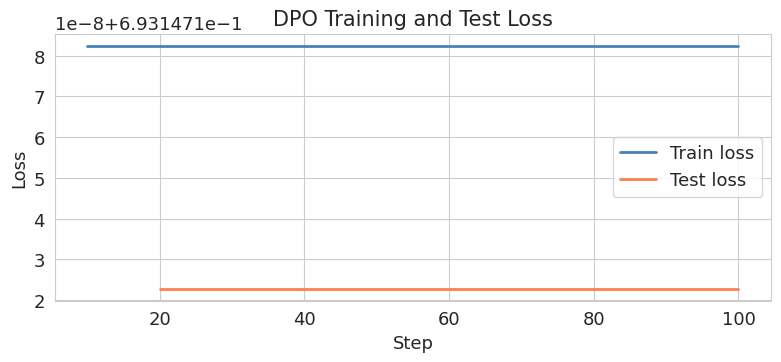

DPO aligns the model to distinguish correct summaries from random ones.


In [46]:
# ── Visualization: DPO Train and Test Loss ──
if dpo_log:
    dpo_loss_log = [e for e in dpo_log if "loss" in e]
    if dpo_loss_log:
        plot_train_eval_curves(
            dpo_log,
            train_metric="loss",
            eval_metric="eval_loss",
            title="DPO Training and Test Loss",
            eval_label="Test loss",
        )
    print("DPO aligns the model to distinguish correct summaries from random ones.")
else:
    print("(No training log — loaded from checkpoint)")

<a id="grpo"></a>

---
## Section 7: GRPO with Rule-Based Rewards

**Group Relative Policy Optimization (GRPO)** is a reinforcement learning method for LLMs:

1. For each prompt, **sample multiple completions** from the current model
2. **Score** each completion with reward functions
3. **Update** the policy toward higher-reward completions

Key advantages for our use case:
- **No reward model needed** — we use simple, deterministic Python functions

- `beta=0.0` skips loading a reference model → saves GPU memory- Extra dataset columns (like `gold_summary`) are passed directly into reward functions

In [47]:
# Prepare GRPO dataset (smaller subset for speed)
from datasets import Dataset

MAX_COMPLETION_LEN = 128
MAX_PROMPT_LEN = config.n_positions - MAX_COMPLETION_LEN

def to_grpo(ex):
    prompt = (
        "Convert the following clinical note into a structured JSON medical record.\n\n"
        f"Clinical note:\n{ex['note']}\n\nJSON:\n"
    )
    ids = tokenizer.encode(prompt, truncation=True, max_length=MAX_PROMPT_LEN)
    prompt = tokenizer.decode(ids, skip_special_tokens=True)
    return {"prompt": prompt, "gold_summary": ex["summary"]}

# Use a smaller subset for GRPO (faster training)
grpo_subset = train_ds.select(range(min(500, len(train_ds))))
grpo_train = grpo_subset.map(to_grpo, remove_columns=grpo_subset.column_names)

print(f"GRPO training examples: {len(grpo_train)}")
print(f"\nExample prompt (first 150 chars):\n{grpo_train[0]['prompt'][:150]}...")

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

GRPO training examples: 500

Example prompt (first 150 chars):
Con ver t the following clinical note into a struc tured J S O N medical record . Clinical note : A 60 - year - old man presented with a 16 × 6 cm2 op...


In [48]:
# Define three reward functions

def json_validity_reward(completions, **kwargs):
    """1.0 if the completion is valid JSON, else 0.0."""
    rewards = []
    for c in completions:
        try:
            json.loads(c)
            rewards.append(1.0)
        except (json.JSONDecodeError, TypeError):
            rewards.append(0.0)
    return rewards


def schema_reward(completions, gold_summary=None, **kwargs):
    """Fraction of required top-level keys present."""
    if gold_summary is None:
        return [0.0] * len(completions)
    rewards = []
    for c, gold in zip(completions, gold_summary):
        try:
            pred = json.loads(c)
            ref = json.loads(gold)
            if isinstance(pred, dict) and isinstance(ref, dict) and len(ref) > 0:
                rewards.append(len(set(pred.keys()) & set(ref.keys())) / len(ref))
            else:
                rewards.append(0.0)
        except (json.JSONDecodeError, TypeError):
            rewards.append(0.0)
    return rewards


def reference_overlap_reward(completions, gold_summary=None, **kwargs):
    """Jaccard-like overlap of parsed key-value pairs with gold."""
    if gold_summary is None:
        return [0.0] * len(completions)
    rewards = []
    for c, gold in zip(completions, gold_summary):
        try:
            pred = json.loads(c)
            ref = json.loads(gold)
            if isinstance(pred, dict) and isinstance(ref, dict):
                pred_items = set((str(k), str(v)) for k, v in pred.items())
                ref_items = set((str(k), str(v)) for k, v in ref.items())
                union = pred_items | ref_items
                rewards.append(len(pred_items & ref_items) / len(union) if union else 0.0)
            else:
                rewards.append(0.0)
        except (json.JSONDecodeError, TypeError):
            rewards.append(0.0)
    return rewards

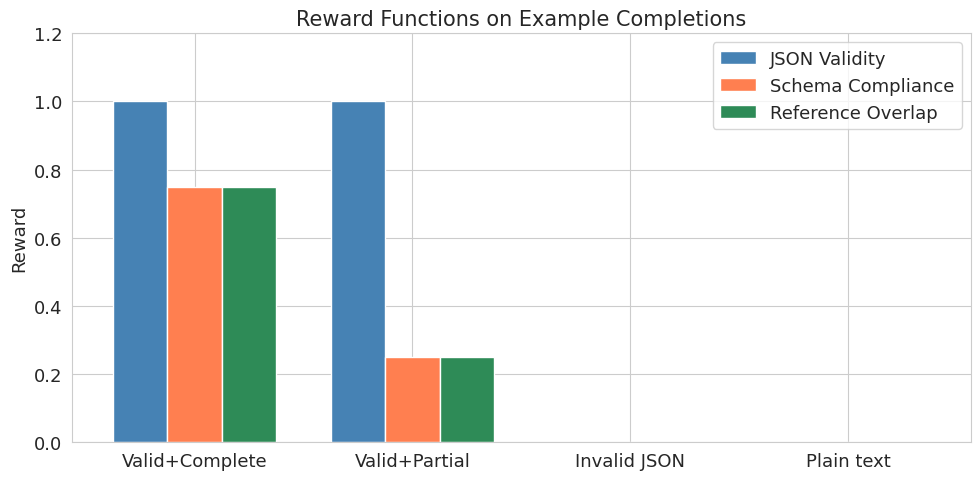

Teaching point: rewards are interpretable and deterministic — no neural reward model needed.


In [49]:
# ── Visualization 18: Reward function demo ──
demo_completions = [
    '{"patient_name": "John Doe", "diagnosis": "hypertension", "age": 55}',
    '{"patient_name": "John Doe"}',
    '{invalid json here',
    'The patient has hypertension and takes medication daily.',
]
demo_gold = '{"patient_name": "John Doe", "diagnosis": "hypertension", "age": 55, "medications": ["lisinopril"]}'
demo_golds = [demo_gold] * len(demo_completions)

demo_labels = ["Valid+Complete", "Valid+Partial", "Invalid JSON", "Plain text"]

r1 = json_validity_reward(demo_completions)
r2 = schema_reward(demo_completions, gold_summary=demo_golds)
r3 = reference_overlap_reward(demo_completions, gold_summary=demo_golds)

x = np.arange(len(demo_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, r1, width, label="JSON Validity", color="steelblue")
ax.bar(x, r2, width, label="Schema Compliance", color="coral")
ax.bar(x + width, r3, width, label="Reference Overlap", color="seagreen")

ax.set_xticks(x)
ax.set_xticklabels(demo_labels)
ax.set_ylabel("Reward")
ax.set_title("Reward Functions on Example Completions")
ax.set_ylim(0, 1.2)
ax.legend()
plt.tight_layout()
plt.show()
print("Teaching point: rewards are interpretable and deterministic — no neural reward model needed.")

In [50]:
# Configure GRPOTrainer
from trl import GRPOConfig, GRPOTrainer

# Save SFT model state for later comparison
sft_model_state = {k: v.clone() for k, v in model.state_dict().items()}

use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

grpo_config_params = inspect.signature(GRPOConfig.__init__).parameters

grpo_config_kwargs = dict(
    output_dir="grpo_clinical_gpt",
    learning_rate=1e-5,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    max_steps=100,
    num_generations=2,
    max_completion_length=MAX_COMPLETION_LEN,
    beta=0.0,  # no reference model → saves memory
    logging_steps=5,
    bf16=use_bf16,
    fp16=not use_bf16 and torch.cuda.is_available(),
    save_strategy="no",
    report_to="none",
    remove_unused_columns=False,
)

# Handle max_prompt_length if supported
if "max_prompt_length" in grpo_config_params:
    grpo_config_kwargs["max_prompt_length"] = MAX_PROMPT_LEN

grpo_config = GRPOConfig(**grpo_config_kwargs)

In [51]:
# Train GRPO or load checkpoint
if not USE_PRECOMPUTED:
    grpo_trainer = GRPOTrainer(
        model=model,
        processing_class=tokenizer,
        args=grpo_config,
        train_dataset=grpo_train,
        reward_funcs=[json_validity_reward, schema_reward, reference_overlap_reward],
    )
    grpo_trainer.train()
    model.save_pretrained("grpo_clinical_gpt")
    tokenizer.save_pretrained("grpo_clinical_gpt")
    grpo_log = grpo_trainer.state.log_history
    print("GRPO training complete!")
else:
    ckpt_path = os.path.join(CHECKPOINT_DIR, "grpo")
    model = GPT2LMHeadModel.from_pretrained(ckpt_path, attn_implementation="eager").to(device)
    grpo_log = []
    print(f"Loaded GRPO model from {ckpt_path}")

Passing `generation_config` together with generation-related arguments=({'disable_compile'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Step,Training Loss
5,0.000000
10,0.000000
15,0.000000
20,0.000000
25,0.000000
30,0.000000
35,0.000000
40,0.000000
45,0.000000
50,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

GRPO training complete!


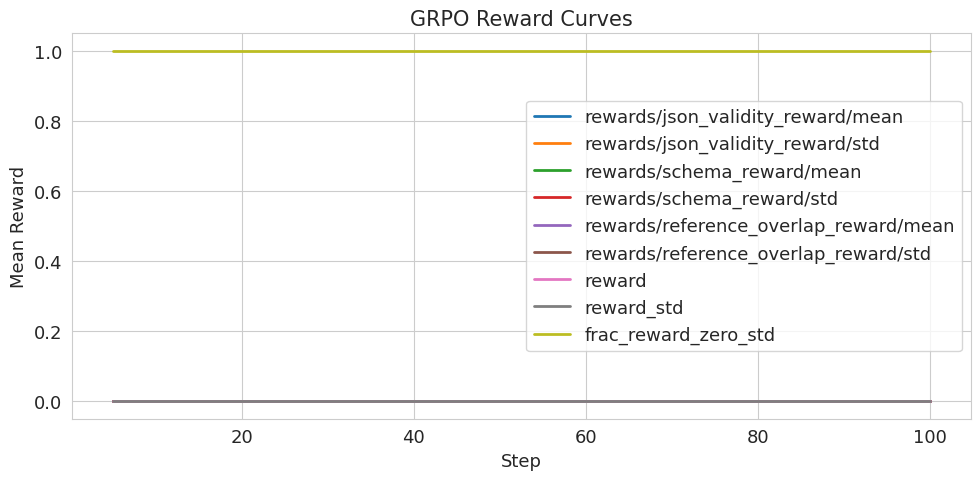

Teaching point: rewards improve over training — the model learns to produce better JSON.


In [52]:
# ── Visualization 19: Reward curves during GRPO training ──
if grpo_log:
    # Try to extract reward metrics from log
    reward_keys = [k for k in grpo_log[0].keys() if "reward" in k.lower()] if grpo_log else []

    if reward_keys:
        fig, ax = plt.subplots(figsize=(10, 5))
        for key in reward_keys:
            steps = [e["step"] for e in grpo_log if key in e]
            vals  = [e[key] for e in grpo_log if key in e]
            if steps:
                ax.plot(steps, vals, linewidth=2, label=key)
        ax.set_xlabel("Step")
        ax.set_ylabel("Mean Reward")
        ax.set_title("GRPO Reward Curves")
        ax.legend()
        plt.tight_layout()
        plt.show()
    else:
        # Fallback: plot loss
        plot_training_curve(grpo_log, metric="loss", title="GRPO Training Loss")

    print("Teaching point: rewards improve over training — the model learns to produce better JSON.")
else:
    print("(No training log — loaded from checkpoint)")

In [53]:
# Generate from GRPO model on the same test examples
grpo_model = model

grpo_outputs = []
for prompt in test_prompts:
    out = generate_text(grpo_model, tokenizer, prompt, max_new_tokens=128, temperature=0.3)
    grpo_outputs.append(out)

for i in range(n_test_examples):
    print(f"\n{'='*60}")
    print(f"Test example {i+1}")
    print(f"GRPO output (first 300 chars):\n{grpo_outputs[i][:300]}")


Test example 1
GRPO output (first 300 chars):
{ " visit motivation ": " None ", " admission ": [ { " admission ": " admission ": " None ", " None ", " None ", " care center details ": " duration ": " None ", " care center details ": " None " None " None " patient information ": " patient information ": " patient information ": " None ", " patie

Test example 2
GRPO output (first 300 chars):
{ " visit motivation ": " None ", " admission ": " admission ": [ { " reason ": " None ", " None ", " None ", " None ", " care center details ": " None " care center details ": " None " patient information ": " patient information ": " None " patient information ": " patient information ": " patient

Test example 3
GRPO output (first 300 chars):
{ " visit motivation ": " }, [ { " admission ": [ { " admission ": " None ", " None ", " reason ": " None ", " None ", " None ", " patient medical history ": " None ", " patient medical history ": " patient information ": " patient information ": " patient 

<a id="compare"></a>

---
## Section 8: Compare the Models

We now have three checkpoints from the **same architecture**, trained with increasingly specialized objectives:

1. **Pretrained** — learned clinical language patterns (next-token prediction)

2. **SFT** — learned to follow instructions and produce structured JSON3. **GRPO** — optimized for JSON validity, schema compliance, and reference overlap

In [54]:
# Load all three models for comparison
pretrained_model = GPT2LMHeadModel(config).to(device)
pretrained_model.load_state_dict(pretrained_model_state)

sft_model_compare = GPT2LMHeadModel(config).to(device)
sft_model_compare.load_state_dict(sft_model_state)

grpo_model_compare = model  # current model is the GRPO model

# Generate from all three on held-out test notes
n_compare = 3
compare_prompts = [to_sft(test_ds[i])["prompt"] for i in range(n_compare)]
compare_notes = [test_ds[i]["note"][:200] + "..." for i in range(n_compare)]

pt_outs, sft_outs, grpo_outs = [], [], []
for prompt in compare_prompts:
    pt_outs.append(generate_text(pretrained_model, tokenizer, prompt, max_new_tokens=128, temperature=0.3))
    sft_outs.append(generate_text(sft_model_compare, tokenizer, prompt, max_new_tokens=128, temperature=0.3))
    grpo_outs.append(generate_text(grpo_model_compare, tokenizer, prompt, max_new_tokens=128, temperature=0.3))

In [55]:
# ── Visualization 20: Side-by-side output comparison ──
rows = []
for i in range(n_compare):
    rows.append([
        compare_notes[i],
        f'<span style="color:black; background:#e0e0e0; padding:2px 4px;">{pt_outs[i][:250]}</span>',
        f'<span style="color:black; background:#bbdefb; padding:2px 4px;">{sft_outs[i][:250]}</span>',
        f'<span style="color:black; background:#c8e6c9; padding:2px 4px;">{grpo_outs[i][:250]}</span>',
    ])

display_comparison_table(
    rows,
    columns=["Clinical Note", "Pretrained (gray bg)", "SFT (blue bg)", "GRPO (green bg)"],
    title="Three Models, Same Architecture, Same Task"
)

Clinical Note,Pretrained (gray bg),SFT (blue bg),GRPO (green bg)
A 32-year-old healthy pregnant woman with more than 30 gestational weeks was admitted to the hospital due to the fetal cardiac mass. The fetal echocardiography showed a heterogeneous lesion of 2.85 cm...,the right side of the right upper limb . The patient was performed for the patient was seen in the patient was performed . The patient was performed . The patient was performed in the patient was performed . The patient was a history of the patient w,"{ "" visit motivation "": "" motivation "": [ { "" reason "": [ { "" reason "": "" None "", "" None "", "" None "", "" duration "": "" None "", "" care center details "": "" None "", "" None "" patient information "": "" None "" patient information "": "" patient information "":","{ "" visit motivation "": "" ], "" admission "": [ { "" admission "": [ { "" None "", "" reason "": "" None "", "" None "", "" None "", "" care center details "": "" care center details "": "" care center details "": "" None "" patient information "": "" patient information "":"
"A 60 years old male presented in June 2010, to our department with complaints of severe pain and swelling in left hip and upper thigh region since last 2 days, following a history of trauma. He was un...",the right side of the patient was performed . The patient was not have a large lesion was performed . The patient was performed . The patient was performed . The patient was performed in the right side of the patient was performed . The patient was p,"{ "" visit motivation "": "" }, "" admission "": "" admission "": "" admission "": [ { "" None "", "" None "", "" None "", "" None "", "" None "" care center details "": "" age "": "" None "" care center details "": "" patient information "": "" patient information "": "" None "",","{ "" visit motivation "": "" None "", "" admission "": "" admission "": [ { "" reason "": "" None "", "" None "", "" None "", "" care center details "": "" None "", "" patient information "": "" None "" None "" None "" patient medical history "": "" patient information "": "" pat"
A 31-year-old gravida 3 para 1 patient presented to antenatal clinic at 19 weeks and 3 days' gestation to discuss the results of her morphology scan which had demonstrated a grade 4 placenta previa co...,2 . The patient was performed and was not have a history of the patient was performed . The patient was performed . The patient was performed . The patient was observed . The patient was performed . The patient was referred to the patient was no hist,"{ "" visit motivation "": "" None "", "" admission "": [ { "" admission "": "" reason "": "" None "", "" None "", "" duration "": "" None "", "" care center details "": "" None "", "" None "", "" None "" None "" patient medical history "": "" patient information "": "" patient med","{ "" visit motivation "": "" ], "" admission "": [ { "" reason "": "" reason "": "" None "", "" None "", "" None "", "" None "", "" None "", "" care center details "": "" patient information "": "" None "", "" patient information "": "" None "" patient medical history "": "" patie"


In [56]:
# Quantitative evaluation across the test set
n_final_eval = min(50, len(test_ds))

results = {"Pretrained": {"json_valid": [], "schema": [], "overlap": []},
           "SFT":        {"json_valid": [], "schema": [], "overlap": []},
           "GRPO":       {"json_valid": [], "schema": [], "overlap": []}}

models_dict = {
    "Pretrained": pretrained_model,
    "SFT": sft_model_compare,
    "GRPO": grpo_model_compare,
}

for i in range(n_final_eval):
    prompt = to_sft(test_ds[i])["prompt"]
    gold = test_ds[i]["summary"]

    for name, m in models_dict.items():
        out = generate_text(m, tokenizer, prompt, max_new_tokens=128, temperature=0.3)
        results[name]["json_valid"].append(is_valid_json(out))
        results[name]["schema"].append(schema_compliance(out, gold))
        results[name]["overlap"].append(reference_overlap(out, gold))

# Summary DataFrame
summary_df = pd.DataFrame({
    name: {
        "JSON Validity": np.mean(vals["json_valid"]),
        "Schema Compliance": np.mean(vals["schema"]),
        "Reference Overlap": np.mean(vals["overlap"]),
    }
    for name, vals in results.items()
}).T

print(f"Evaluation on {n_final_eval} test examples:\n")
print(summary_df.to_string(float_format=lambda x: f"{x:.1%}"))

Evaluation on 50 test examples:

            JSON Validity  Schema Compliance  Reference Overlap
Pretrained           0.0%               0.0%               0.0%
SFT                  0.0%               0.0%               0.0%
GRPO                 0.0%               0.0%               0.0%


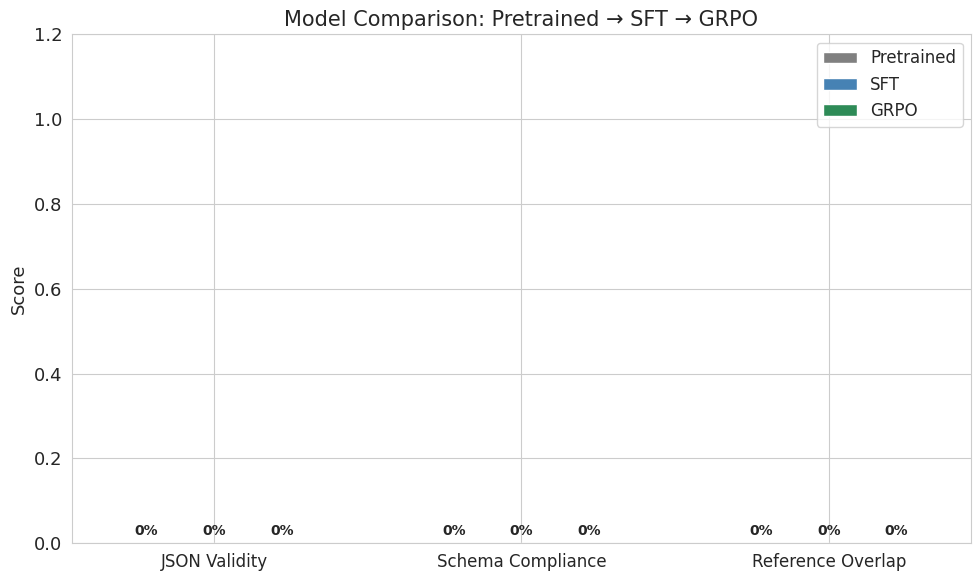

In [57]:
# ── Visualization 21: Final grouped bar chart ──
metrics = ["JSON Validity", "Schema Compliance", "Reference Overlap"]
model_names = ["Pretrained", "SFT", "GRPO"]
model_colors = ["gray", "steelblue", "seagreen"]

x = np.arange(len(metrics))
width = 0.22

fig, ax = plt.subplots(figsize=(10, 6))

for j, (name, color) in enumerate(zip(model_names, model_colors)):
    vals = [summary_df.loc[name, m] for m in metrics]
    bars = ax.bar(x + (j - 1) * width, vals, width, label=name, color=color, edgecolor="white")
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f"{h:.0%}", ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.2)
ax.set_title("Model Comparison: Pretrained → SFT → GRPO", fontsize=15)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

In [58]:
# Clean up
del pretrained_model, sft_model_compare
if torch.cuda.is_available():
    torch.cuda.empty_cache()

---
## Wrap-Up and Takeaways

### The Journey

```
Clinical Notes → Tokenization → Embeddings → Attention → Pretraining → SFT → GRPO
    (data)       (BPE 8K)      (256-dim)    (4 heads)   (500 steps)  (300) (100)
```

### Key Lessons

1. **Tokenization determines what the model can learn.** A domain tokenizer keeps clinical terms intact, making the model more efficient.

2. **Pretraining gives language understanding.** Next-token prediction on clinical notes teaches the model what clinical text *sounds like* — vocabulary, syntax, common patterns.

3. **SFT teaches instruction following.** The model learns to produce structured JSON from clinical notes — but only for patterns seen during training.

4. **DPO and GRPO improve output quality** by either ranking preferences or optimizing for measurable rewards, without retraining from scratch.

<a id="peft"></a>

---
## Section 9 (Optional): Parameter-Efficient Fine-Tuning (PEFT)

In Sections 5–7 we fine-tuned **all** parameters of our tiny 5M-param model. That works at this scale, but real LLMs have **billions** of parameters — fine-tuning everything is prohibitively expensive in both memory and compute.

**Parameter-Efficient Fine-Tuning (PEFT)** solves this by training only a small number of additional parameters while keeping the original weights frozen.

### Why PEFT?

- **Memory:** A 4-bit Llama 3 8B fits in ~6 GB VRAM; full fine-tuning needs >60 GB
- **Speed:** Training ~1–2% of parameters is much faster
- **Performance:** Reuses the powerful base model — the adapter learns only the task-specific correction

Typical biomedical use cases:
- Adapting a general LLM to clinical language

- Enforcing structured outputs (JSON report templates)- Reducing hallucinations via supervised examples

### LoRA: Low-Rank Adaptation

The key insight of LoRA ([Hu et al., 2021](https://arxiv.org/abs/2106.09685)) is that **weight updates during fine-tuning have low intrinsic rank** — most of the useful signal lives in a small subspace.

Instead of updating the full weight matrix $W_0 \in \mathbb{R}^{d \times k}$ directly, LoRA adds a **low-rank perturbation**:

$$W = W_0 + \Delta W = W_0 + BA$$

| Matrix | Shape | Role |
|--------|-------|------|
| $W_0$ | $d \times k$ | **Frozen** pre-trained weight |
| $A$ | $r \times k$ | Trainable; initialized from $\mathcal{N}(0, \sigma^2)$ |
| $B$ | $d \times r$ | Trainable; initialized to **zero** (so $\Delta W = 0$ at start) |
| $r$ | scalar | Rank, $r \ll \min(d, k)$ (e.g., 8–64) |

The forward pass through an adapted layer:

$$h = W_0 x + \frac{\alpha}{r} B A x$$

where $\alpha$ is a scaling hyperparameter (`lora_alpha`). Since $B$ starts at zero, the model begins exactly at the pre-trained behavior and gradually learns the task-specific correction.

**Parameter savings:** For $d = k = 4096$ and $r = 16$, LoRA trains $16 \times 8192 = 131{,}072$ parameters vs. $4096^2 = 16{,}777{,}216$ for full fine-tuning — a **128x reduction** per layer.

In [59]:
# ── LoRA on our tiny clinical GPT ──
from peft import LoraConfig, get_peft_model

# Clear GPU state from previous sections
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

# Rebuild the pretrained model fresh (avoids stale CUDA state from GRPO)
lora_config_fresh = GPT2Config(
    vocab_size=len(tokenizer),
    n_positions=256,
    n_embd=256,
    n_layer=4,
    n_head=4,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
)
lora_config_fresh._attn_implementation = "eager"

lora_base_model = GPT2LMHeadModel(lora_config_fresh)
lora_base_model.load_state_dict(pretrained_model_state)
lora_base_model = lora_base_model.to(device)

# Verify vocab alignment
assert lora_base_model.config.vocab_size == len(tokenizer), \
    f"Vocab mismatch: model={lora_base_model.config.vocab_size}, tokenizer={len(tokenizer)}"

# Ensure tokenizer won't produce sequences longer than model can handle
tokenizer.model_max_length = 256

# Configure LoRA: r=8, targeting all linear layers
lora_cfg = LoraConfig(
    r=8,                           # rank — capacity of adapter
    lora_alpha=16,                 # scaling factor; effective scale = α/r = 2.0
    lora_dropout=0.05,             # dropout on adapter path for regularization
    bias="none",                   # do not train bias terms
    target_modules="all-linear",   # apply ΔW = BA to every linear layer
    task_type="CAUSAL_LM",
)

lora_model = get_peft_model(lora_base_model, lora_cfg)
lora_model.print_trainable_parameters()

trainable params: 131,072 || all params: 5,404,160 || trainable%: 2.4254


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Layer: base_model.model.transformer.h.0.attn.c_attn
  A shape (r × k): torch.Size([8, 256])
  B shape (d × r): torch.Size([768, 8])
  → Adapter params: 8,192


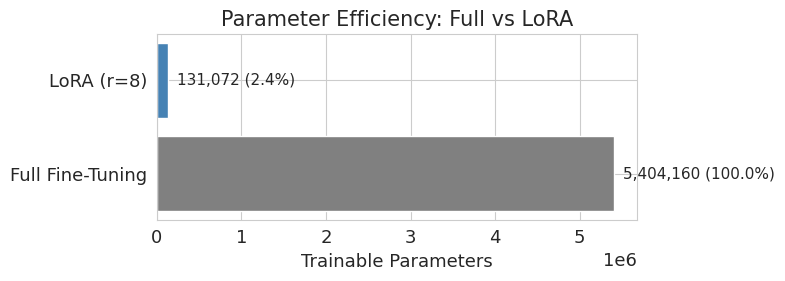

LoRA trains 131,072 / 5,404,160 = 2.4% of parameters


In [60]:
# Inspect the actual LoRA adapter matrices inside the model
for name, module in lora_model.named_modules():
    if hasattr(module, "lora_A"):
        print(f"Layer: {name}")
        print(f"  A shape (r × k): {module.lora_A['default'].weight.shape}")
        print(f"  B shape (d × r): {module.lora_B['default'].weight.shape}")
        print(f"  → Adapter params: {module.lora_A['default'].weight.numel() + module.lora_B['default'].weight.numel():,}")
        break

# Visualize: full fine-tuning vs LoRA parameter counts
total_params = sum(p.numel() for p in lora_model.parameters())
trainable_params = sum(p.numel() for p in lora_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

fig, ax = plt.subplots(figsize=(8, 3))
ax.barh(["Full Fine-Tuning", "LoRA (r=8)"],
        [total_params, trainable_params],
        color=["gray", "steelblue"], edgecolor="white")
ax.set_xlabel("Trainable Parameters")
ax.set_title("Parameter Efficiency: Full vs LoRA")
for i, v in enumerate([total_params, trainable_params]):
    ax.text(v + total_params * 0.02, i, f"{v:,} ({v/total_params:.1%})",
            va="center", fontsize=11)
plt.tight_layout()
plt.show()
print(f"LoRA trains {trainable_params:,} / {total_params:,} = {trainable_params/total_params:.1%} of parameters")

In [61]:
# ── Train LoRA SFT on the same clinical note → JSON task ──
from trl import SFTTrainer, SFTConfig

# Use a smaller subset and fewer steps for LoRA demo (faster, avoids OOM after GRPO)
lora_train_subset = sft_train.select(range(min(1000, len(sft_train))))
lora_eval_subset = sft_test.select(range(min(200, len(sft_test))))

lora_sft_config = SFTConfig(
    output_dir="lora_sft_clinical_gpt",
    max_length=256,
    max_steps=200,
    per_device_train_batch_size=4,
    learning_rate=2e-4,
    warmup_steps=30,
    logging_steps=10,
    eval_steps=20,
    eval_strategy="steps",
    fp16=torch.cuda.is_available(),
    save_strategy="no",
    report_to="none",
    seed=SEED,
)

lora_sft_kwargs = dict(
    model=lora_model,
    train_dataset=lora_train_subset,
    eval_dataset=lora_eval_subset,
    args=lora_sft_config,
)
params = inspect.signature(SFTTrainer.__init__).parameters
if "tokenizer" in params:
    lora_sft_kwargs["tokenizer"] = tokenizer
elif "processing_class" in params:
    lora_sft_kwargs["processing_class"] = tokenizer

lora_sft_trainer = SFTTrainer(**lora_sft_kwargs)
lora_sft_trainer.train()
lora_sft_log = lora_sft_trainer.state.log_history
print("LoRA SFT training complete!")

Adding EOS to train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (793 > 256). Running this sequence through the model will result in indexing errors


Truncating train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss
20,10.229433,10.139231
40,9.047002,8.691973
60,7.846884,7.569372
80,7.159746,6.986392
100,6.841692,6.756066
120,6.747719,6.593276
140,6.550677,6.456242
160,6.521326,6.358256
180,6.412329,6.300808
200,6.383665,6.280859


LoRA SFT training complete!


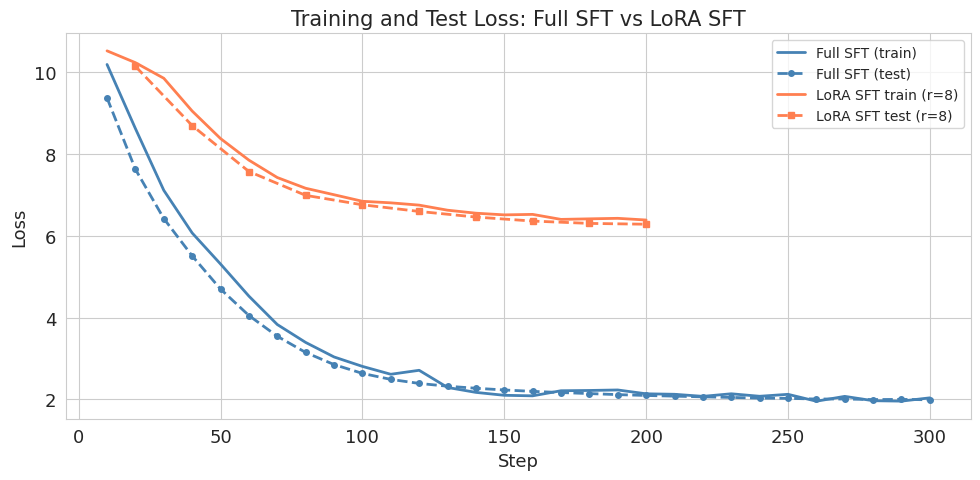


LoRA SFT Evaluation (50 examples):
  JSON validity: 0.0%
  Schema compliance: 0.0%
  Reference overlap: 0.0%

Full SFT (for comparison):
  JSON validity: 0.0%
  Schema compliance: 0.0%
  Reference overlap: 0.0%


In [62]:
# ── Compare: Full SFT vs LoRA SFT ──
# Loss curves side by side (train and test)
fig, ax = plt.subplots(figsize=(10, 5))

if sft_log:
    steps_full = [e["step"] for e in sft_log if "loss" in e]
    loss_full = [e["loss"] for e in sft_log if "loss" in e]
    ax.plot(steps_full, loss_full, linewidth=2, label="Full SFT (train)", color="steelblue")
    eval_steps_full = [e["step"] for e in sft_log if "eval_loss" in e]
    eval_loss_full = [e["eval_loss"] for e in sft_log if "eval_loss" in e]
    if eval_steps_full:
        ax.plot(eval_steps_full, eval_loss_full, linewidth=2, linestyle="--",
                marker="o", markersize=4, label="Full SFT (test)", color="steelblue")

if lora_sft_log:
    steps_lora = [e["step"] for e in lora_sft_log if "loss" in e]
    loss_lora = [e["loss"] for e in lora_sft_log if "loss" in e]
    ax.plot(steps_lora, loss_lora, linewidth=2, label="LoRA SFT train (r=8)", color="coral")
    eval_steps_lora = [e["step"] for e in lora_sft_log if "eval_loss" in e]
    eval_loss_lora = [e["eval_loss"] for e in lora_sft_log if "eval_loss" in e]
    if eval_steps_lora:
        ax.plot(eval_steps_lora, eval_loss_lora, linewidth=2, linestyle="--",
                marker="s", markersize=4, label="LoRA SFT test (r=8)", color="coral")

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training and Test Loss: Full SFT vs LoRA SFT")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Evaluate LoRA model on test set
lora_model.eval()
n_eval_lora = min(50, len(test_ds))
lora_json_valid, lora_schema, lora_overlap = [], [], []

for i in range(n_eval_lora):
    prompt = to_sft(test_ds[i])["prompt"]
    gold = test_ds[i]["summary"]
    out = generate_text(lora_model, tokenizer, prompt, max_new_tokens=128, temperature=0.3)
    lora_json_valid.append(is_valid_json(out))
    lora_schema.append(schema_compliance(out, gold))
    lora_overlap.append(reference_overlap(out, gold))

print(f"\nLoRA SFT Evaluation ({n_eval_lora} examples):")
print(f"  JSON validity: {np.mean(lora_json_valid):.1%}")
print(f"  Schema compliance: {np.mean(lora_schema):.1%}")
print(f"  Reference overlap: {np.mean(lora_overlap):.1%}")
print(f"\nFull SFT (for comparison):")
print(f"  JSON validity: {np.mean(sft_json_valid):.1%}")
print(f"  Schema compliance: {np.mean(sft_schema):.1%}")
print(f"  Reference overlap: {np.mean(sft_overlap):.1%}")

### Quantization and QLoRA

For billion-parameter models that don't fit in GPU memory at full precision, **quantization** stores weights in lower precision:

| Precision | Bits per param | ~Memory for 8B model |
|-----------|---------------|---------------------|
| float32 | 32 | 32 GB |
| float16 / bfloat16 | 16 | 16 GB |
| int8 | 8 | 8 GB |
| int4 (NF4) | 4 | ~5 GB |

**QLoRA** combines 4-bit quantization with LoRA: the base model $W_0$ stays in 4-bit (frozen), while the LoRA adapter matrices $A$ and $B$ are trained in bfloat16:

$$h = \text{dequant}(W_0^{4\text{bit}}) \cdot x + \frac{\alpha}{r} B A x$$

The quantized weights are dequantized on-the-fly during the forward pass. Gradients only flow through the adapter $BA$, never through $W_0$.

Below we apply QLoRA's training pattern to our tiny clinical GPT — frozen base weights + LoRA adapters trained in fp16. On large models (8B+), the base would additionally be stored in 4-bit NF4 via `BitsAndBytesConfig` to cut memory from 16 GB → 5 GB:

In [64]:
# ── QLoRA on our tiny clinical GPT ──
import inspect
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig

# Rebuild the tiny clinical GPT (same architecture used throughout)
qlora_base_config = GPT2Config(
    vocab_size=len(tokenizer),
    n_positions=256,
    n_embd=256,
    n_layer=4,
    n_head=4,
    bos_token_id=tokenizer.bos_token_id,
    eos_token_id=tokenizer.eos_token_id,
    pad_token_id=tokenizer.pad_token_id,
)
qlora_base_config._attn_implementation = "eager"

qlora_base = GPT2LMHeadModel(qlora_base_config)
qlora_base.load_state_dict(pretrained_model_state)
qlora_base = qlora_base.to(device)
tokenizer.model_max_length = 256

# Quantization memory table — conceptual for our tiny model; critical at 8B+ scale
total_params = sum(p.numel() for p in qlora_base.parameters())
print(f"Our tiny GPT has {total_params:,} parameters. Memory by precision:")
for label, bits in [("FP32", 32), ("FP16/BF16", 16), ("INT8", 8), ("NF4 (QLoRA)", 4)]:
    mb = total_params * bits / (8 * 1e6)
    note = " ← QLoRA stores W₀ here" if bits == 4 else ""
    print(f"  {label:14s}: {mb:.2f} MB{note}")
print("\nFor an 8B model: FP32 ≈ 32 GB → NF4 ≈ 5 GB (fits on a single 24 GB GPU)")
print("Here we freeze the base and train fp16 LoRA adapters — same training pattern as QLoRA.\n")

# Apply LoRA adapters — same config as the LoRA section above
peft_config = LoraConfig(
    r=8,
    lora_alpha=8,           # effective scale α/r = 1.0
    lora_dropout=0.05,
    bias="none",
    target_modules="all-linear",
    task_type="CAUSAL_LM",
)

qlora_model = get_peft_model(qlora_base, peft_config)
qlora_model.print_trainable_parameters()

# Train on the same clinical note → JSON task
qlora_subset = sft_train.select(range(min(500, len(sft_train))))

# Detect correct param name for this TRL version
_sft_params = inspect.signature(SFTConfig.__init__).parameters
qlora_args_kwargs = dict(
    output_dir="qlora_clinical_gpt",
    max_steps=100,
    per_device_train_batch_size=4,
    learning_rate=2e-4,
    warmup_steps=20,
    logging_steps=10,
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=False,
    save_strategy="no",
    report_to="none",
    seed=SEED,
)
if "max_seq_length" in _sft_params:
    qlora_args_kwargs["max_seq_length"] = 256
elif "max_length" in _sft_params:
    qlora_args_kwargs["max_length"] = 256

qlora_args = SFTConfig(**qlora_args_kwargs)

qlora_kwargs = dict(model=qlora_model, train_dataset=qlora_subset, args=qlora_args)
_params = inspect.signature(SFTTrainer.__init__).parameters
if "tokenizer" in _params:
    qlora_kwargs["tokenizer"] = tokenizer
elif "processing_class" in _params:
    qlora_kwargs["processing_class"] = tokenizer

qlora_trainer = SFTTrainer(**qlora_kwargs)
qlora_trainer.train()
print("QLoRA training complete!")

Our tiny GPT has 5,273,088 parameters. Memory by precision:
  FP32          : 21.09 MB
  FP16/BF16     : 10.55 MB
  INT8          : 5.27 MB
  NF4 (QLoRA)   : 2.64 MB ← QLoRA stores W₀ here

For an 8B model: FP32 ≈ 32 GB → NF4 ≈ 5 GB (fits on a single 24 GB GPU)
Here we freeze the base and train fp16 LoRA adapters — same training pattern as QLoRA.

trainable params: 131,072 || all params: 5,404,160 || trainable%: 2.4254


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


Adding EOS to train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/500 [00:00<?, ? examples/s]

Step,Training Loss
10,10.489969
20,10.386914
30,9.931308
40,9.321112
50,8.808914
60,8.521532
70,8.249809
80,7.996361
90,7.866022
100,7.800347


QLoRA training complete!


### Merging Adapters

After QLoRA training, you can **merge** the adapter weights back into the base model for simpler deployment (no PEFT dependency needed at inference):

$$W_{\text{merged}} = W_0 + \frac{\alpha}{r} BA$$

```python
from peft import AutoPeftModelForCausalLM

peft_model = AutoPeftModelForCausalLM.from_pretrained("llama3-8b-qlora", torch_dtype=torch.float16)
merged = peft_model.merge_and_unload()   # computes W₀ + (α/r)BA for each layer
merged.save_pretrained("llama3-8b-merged", safe_serialization=True)
```

### LoRA Hyperparameter Guide

| Setting | Guidance |
|---------|----------|
| `r` (rank) | Start with 16; increase to 64–128 for harder tasks |
| `lora_alpha` | Set equal to `r` (scale = 1) or 2x `r` (scale = 2) |
| `lora_dropout` | 0.05–0.1 for regularization |
| Quant bits | 4-bit for 8B+ models on 24 GB VRAM; 8-bit for extra stability |
| `target_modules` | `"all-linear"` is a good default; restricting to attention-only reduces cost further |

In [65]:
# Clean up PEFT section
del lora_model, lora_base_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("PEFT section complete!")

PEFT section complete!
